# 01-03-2026

## Data Visualization - I

### Agenda:
- Cleaning & Feature Engineering
- Matplotlib Basic
- Line Plot
- Bar Plot

In [1]:
import pandas as pd

In [2]:
# Dataset link -> https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx

In [3]:
df_1 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2010-2011')

In [4]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [5]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
list(df_1.columns)

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [7]:
list(df_2.columns)

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [8]:
df = pd.concat([df_1, df_2], ignore_index=True)

In [9]:
df.shape

(1067371, 8)

In [10]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')


In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df.iloc[100000 : 100005]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
100000,498780,84673B,BLUE FLY SWAT,2,2010-02-23 10:50:00,1.28,NaN,United Kingdom
100001,498780,84750A,PINK SMALL GLASS CAKE STAND,1,2010-02-23 10:50:00,4.21,NaN,United Kingdom
100002,498780,84762C,GREEN PICNIC BARBECUE BUCKET,1,2010-02-23 10:50:00,8.47,NaN,United Kingdom
100003,498780,84854,GIRLY PINK TOOL SET,1,2010-02-23 10:50:00,8.47,NaN,United Kingdom
100004,498780,84970L,SINGLE HEART ZINC T-LIGHT HOLDER,3,2010-02-23 10:50:00,2.13,NaN,United Kingdom


In [13]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


### Cleaning & Feature Engineering

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [15]:
# remove all rows or records where 'Customer ID' is null

df = df.dropna(subset=['Customer ID'])

In [16]:
df.loc[100 : 200]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
100,489442,22271,FELTCRAFT DOLL ROSIE,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
101,489442,22272,FELTCRAFT DOLL MARIA,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
102,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
103,489442,21582,KINGS CHOICE SMALL TUBE MATCHES,20,2009-12-01 09:46:00,1.65,13635.0,United Kingdom
104,489442,21586,KINGS CHOICE GIANT TUBE MATCHES,12,2009-12-01 09:46:00,2.55,13635.0,United Kingdom
...,...,...,...,...,...,...,...,...
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
197,C489459,90200D,PINK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
198,C489459,90200B,BLACK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
199,C489459,90200E,GREEN SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  object        
 1   StockCode    824364 non-null  object        
 2   Description  824364 non-null  object        
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[us]
 5   Price        824364 non-null  float64       
 6   Customer ID  824364 non-null  float64       
 7   Country      824364 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 88.9+ MB


In [18]:
# Remove all rows/records where Invoice startswith 'C*'

df = df[~ df['Invoice'].astype('str').str.startswith('C')]

In [19]:
df.shape

(805620, 8)

In [20]:
print(f'Number of Invoices cancelled: {824364 - 805620}')

Number of Invoices cancelled: 18744


In [21]:
# removing zero/negative quantities

df = df[df['Quantity'] > 0]
df.shape

(805620, 8)

In [22]:
# removing zero/negative price

df = df[df['Price'] > 0]
df.shape

(805549, 8)

In [23]:
df['Revenue'] = df['Quantity'] * df['Price']

In [24]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 61.5+ MB


In [26]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype('str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
 9   Month        805549 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(2)
memory usage: 67.6+ MB


In [28]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


### Matplotlib

#### What is Matplotlib ?

- Matplotlib is a powerful 2D plotting library in Python

- It allows you to create publication-quality figures in a variety of formats (PNG, SVG, PDF, etc.)

- Commonly used module: matplotlib.pyplot often imported as plt


#### Why use Matplotlib ?

- Core plotting engine behind libraries like Seaborn and Pandas plots

- Works with NumPy and Pandas natively

- Gives you low-level control of every visual element (useful for fine-tuning)

In [29]:
import matplotlib.pyplot as plt

In [30]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12


In [31]:
# get monthly revenue

# Step-1: group by month
# Step-2: sum their revenue

dummy_DF = df.groupby('Month')

In [32]:
dummy_DF.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
1041864,579899,23301,GARDENERS KNEELING PAD KEEP CALM,24,2011-12-01 08:33:00,1.65,15687.0,United Kingdom,39.60,2011-12
1041865,579899,22623,BOX OF VINTAGE JIGSAW BLOCKS,3,2011-12-01 08:33:00,5.95,15687.0,United Kingdom,17.85,2011-12
1041866,579899,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,4,2011-12-01 08:33:00,3.75,15687.0,United Kingdom,15.00,2011-12
1041867,579899,23562,SET OF 6 RIBBONS PERFECTLY PRETTY,6,2011-12-01 08:33:00,2.89,15687.0,United Kingdom,17.34,2011-12


In [33]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

In [34]:
monthly_revenue

Month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Name: Revenue, dtype: float64

### Line Plot

In [35]:
data = pd.Series([100, 200, 150, 300], index=['Q1', 'Q2', 'Q3', 'Q4'])

In [36]:
data

Q1    100
Q2    200
Q3    150
Q4    300
dtype: int64

<Axes: >

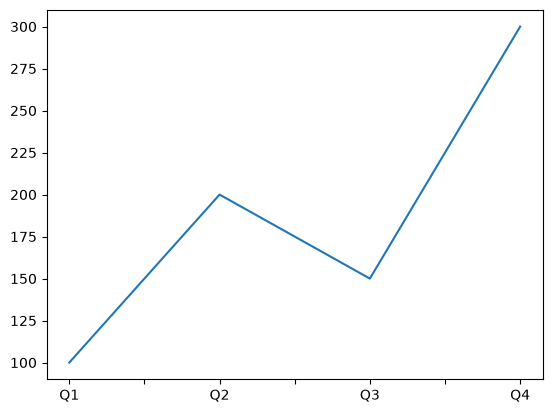

In [37]:
data.plot()

| Marker Symbol | Description |
| :---: | :---: |
| `'o'` | Circle |
| `'.'` | Point |
| `','` | Pixel |
| `'x'` | X |
| `'+'` | Plus |
| `'s'` | Square |
| `'D'` | Diamond |
| `'^'` | Upward Triangle |

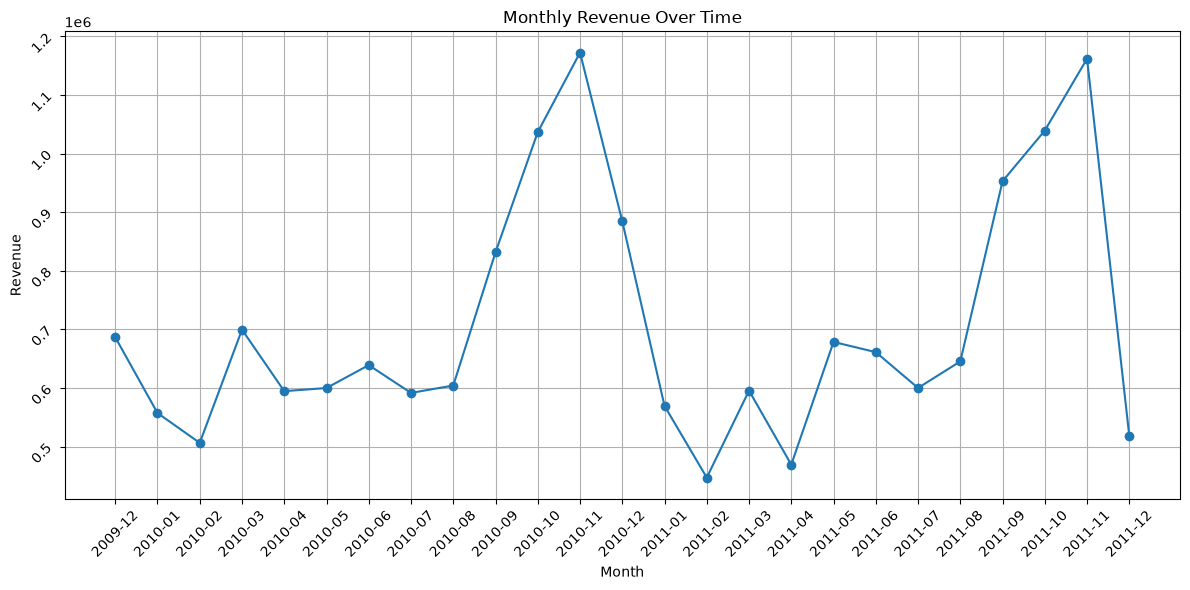

In [38]:
# Steps to create any plot using matplotlib.pyplot

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

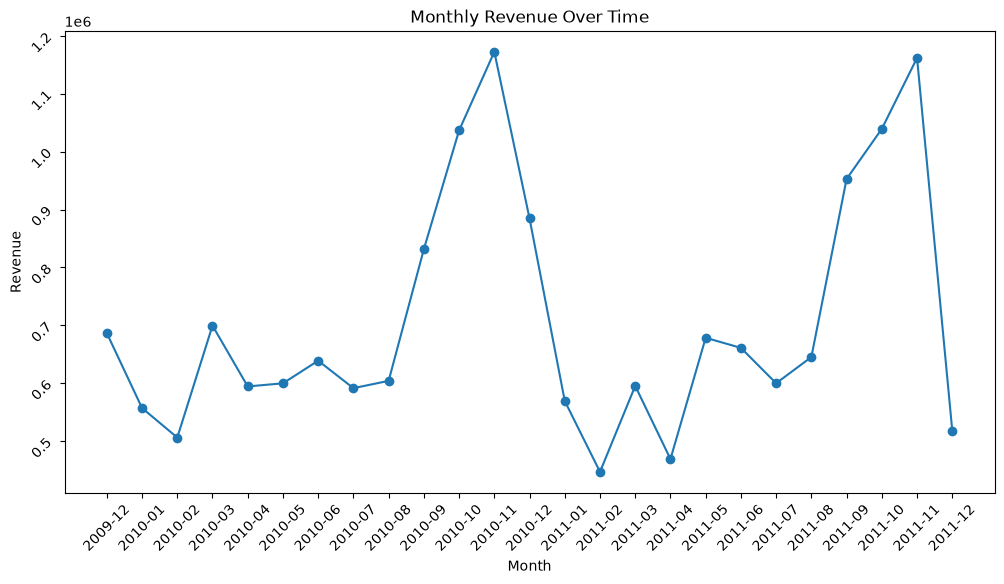

In [39]:
# without grid

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
# plt.tight_layout()

# Step-8: Show grid
# plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

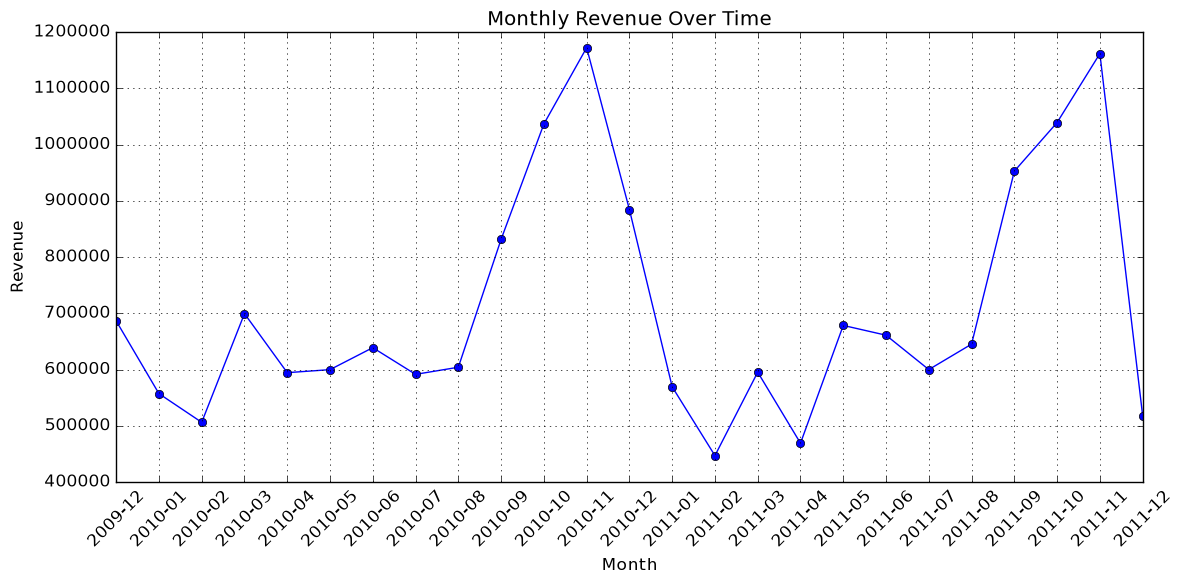

In [40]:
# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

In [41]:
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


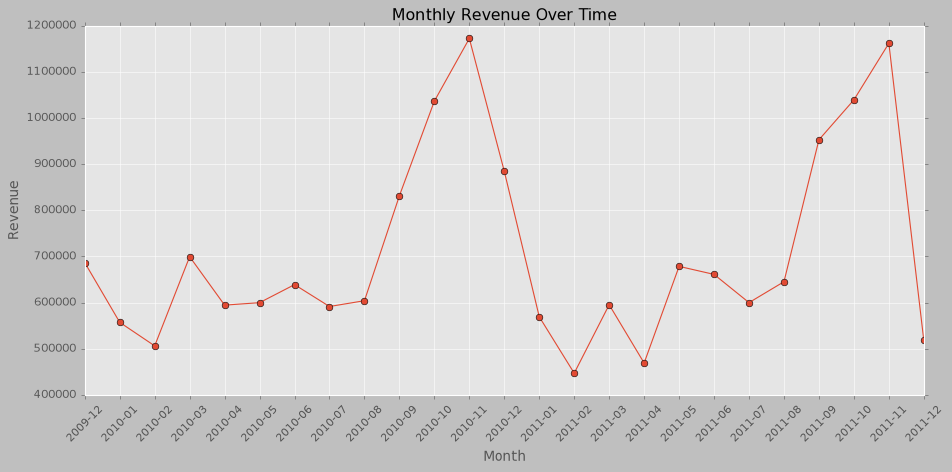

In [42]:
# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('ggplot')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

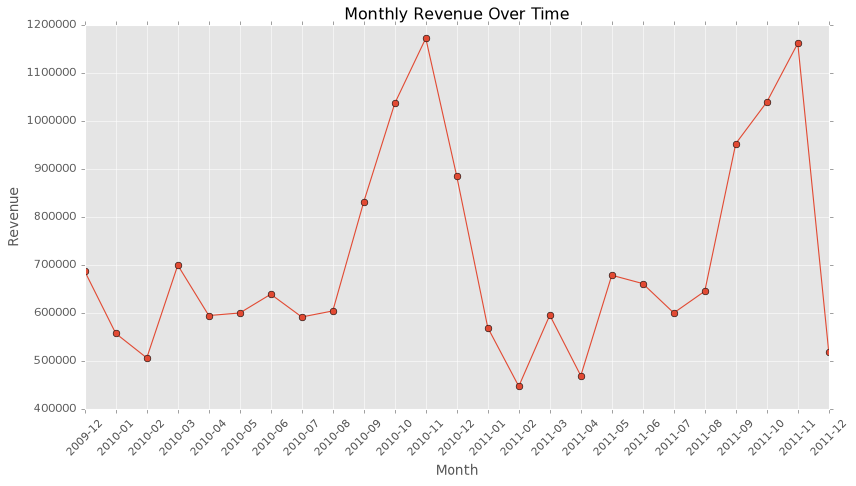

In [43]:
# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('ggplot')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
# plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

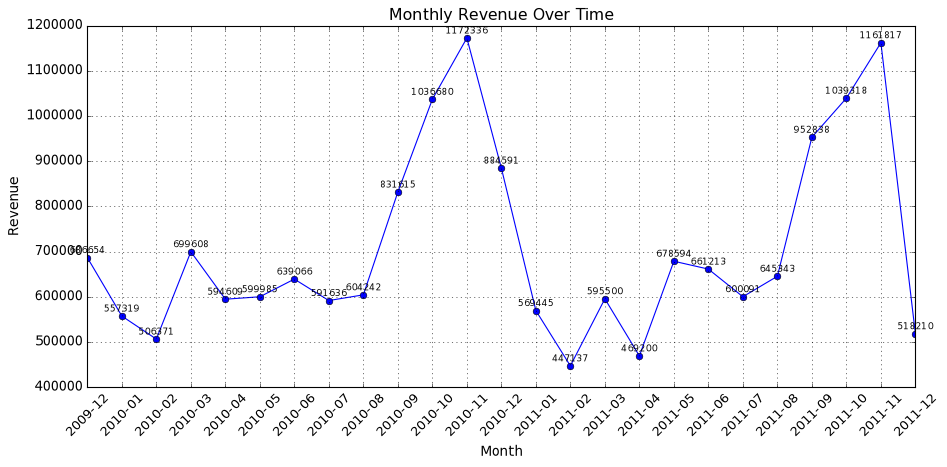

In [44]:
# adding labels on points

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6))

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value + 10000, f'{int(value)}', ha='center', fontsize=8)

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

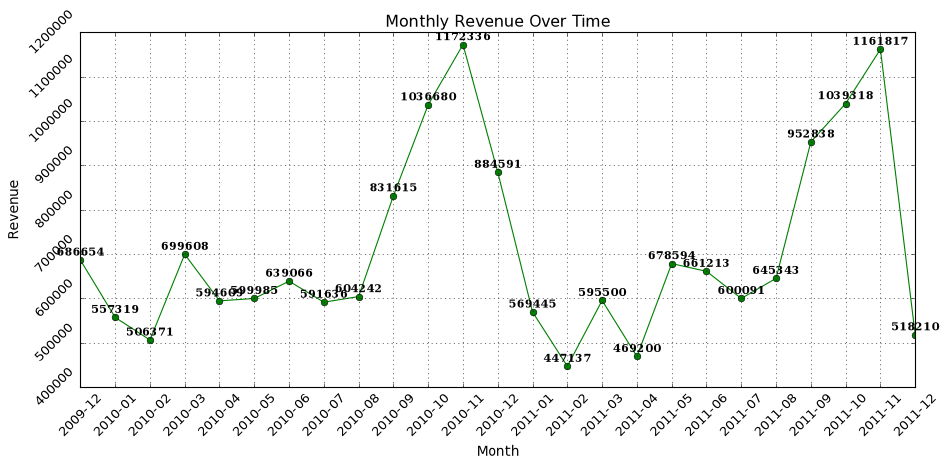

In [45]:
# adding labels on points
# using font-dict

font = {
    'family' : 'serif',
    'color' : 'black',
    'weight' : 'bold',
    'size' : 10
}

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6), facecolor='white')

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='green')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value + 10000, f'{int(value)}', ha='center', fontdict=font)

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

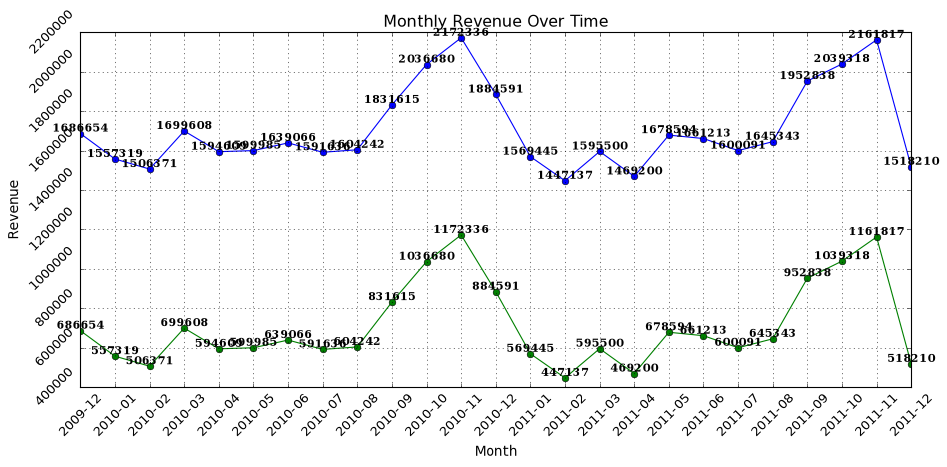

In [46]:
# plotting multiple graphs on the same plot
# adding labels on points
# using font-dict

font = {
    'family' : 'serif',
    'color' : 'black',
    'weight' : 'bold',
    'size' : 10
}

# Step-1: Create a canvas using width & height, (scale : inches)
plt.figure(figsize=(12, 6), facecolor='white')

plt.style.use('classic')

# Step-2: Plot line --> plt.plot()
# The first line plot
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='green')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value + 10000, f'{int(value)}', ha='center', fontdict=font)

# The second line plot
plt.plot(monthly_revenue.index, monthly_revenue.values+1000000, marker='o')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], (value+1000000) + 10000, f'{int(value+1000000)}', ha='center', fontdict=font)

# Step-3: Title of the plot
plt.title('Monthly Revenue Over Time')

# Step-4: X-axis label
plt.xlabel('Month')

# Step-5: Y-axis label
plt.ylabel('Revenue')

# Step-6: Rotate X labels
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Step-7: Fit layout, prevents label clipping
plt.tight_layout()

# Step-8: Show grid
plt.grid(True)

# Step-9: Show the plot window or render the figure
plt.show()

### Bar Plot

In [47]:
# Objective: Show top 10 revenue-generating countries

In [48]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

In [49]:
country_revenue

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

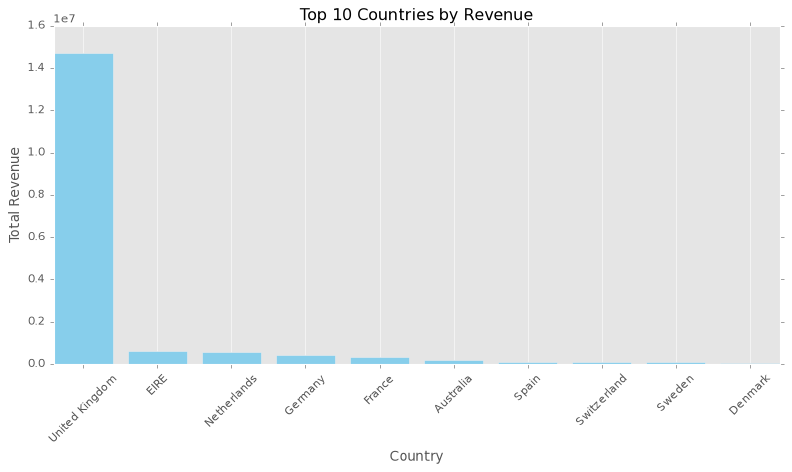

In [118]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.bar(country_revenue.index, country_revenue.values, color='skyblue')
plt.style.use('ggplot')

# Customizations
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')

plt.show()

# 07-03-2026

## Data Visualization - II

### Agenda:
- Scatter Plot
- Subplots
- Saving & Exporting Figures
- Seaborn
- Categorical Data Visualizations

### Scatter Plot

In [51]:
# Scatter Plot: Relationship Between Quantity & Revenue

In [52]:
df.shape

(805549, 10)

In [53]:
# gives 1000 random records from the df
sample_df = df.sample(1000, random_state=10000)

In [54]:
sample_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 889181 to 289878
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      1000 non-null   object        
 1   StockCode    1000 non-null   object        
 2   Description  1000 non-null   object        
 3   Quantity     1000 non-null   int64         
 4   InvoiceDate  1000 non-null   datetime64[us]
 5   Price        1000 non-null   float64       
 6   Customer ID  1000 non-null   float64       
 7   Country      1000 non-null   str           
 8   Revenue      1000 non-null   float64       
 9   Month        1000 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(2)
memory usage: 85.9+ KB


In [55]:
sample_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
889181,568576,22993,SET OF 4 PANTRY JELLY MOULDS,72,2011-09-28 09:40:00,1.06,17017.0,United Kingdom,76.32,2011-09
579860,540946,20704,MR ROBOT SOFT TOY,8,2011-01-12 12:43:00,1.95,12359.0,Cyprus,15.60,2011-01
188131,507243,22558,CLOTHES PEGS RETROSPOT PACK 24,12,2010-05-07 10:19:00,1.25,15312.0,United Kingdom,15.00,2010-05
857557,566057,47341B,BLUE TABLE RUN FLOWER,6,2011-09-08 15:16:00,1.25,17997.0,United Kingdom,7.50,2011-09
423556,529849,22111,SCOTTIE DOG HOT WATER BOTTLE,3,2010-10-31 13:28:00,4.95,14114.0,United Kingdom,14.85,2010-10


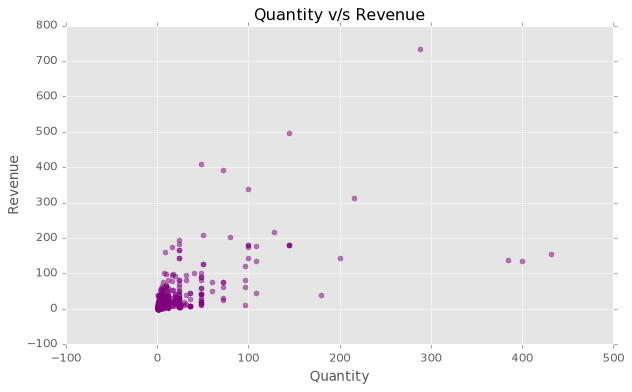

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df['Quantity'], sample_df['Revenue'], alpha=0.5, color='purple')     # alpha : is for transparency
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.title('Quantity v/s Revenue')
plt.grid(True)
plt.tight_layout()      # adds a padding of 1.08 by-default
plt.show()      # it renders the final graph

### Subplots: Multiple Charts in One Figure

In [57]:
# Let's compare monthly Revenue with monthly Quantity

In [58]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [59]:
monthly_quantity = df.groupby('Month')['Quantity'].sum()

# monthly_revenue = df.groupby('Month')['Revenue'].sum()

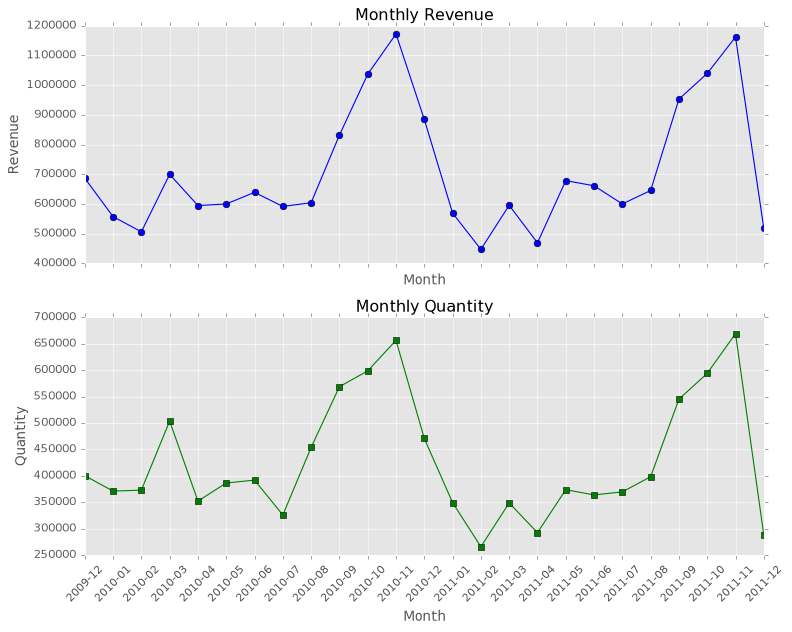

In [60]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

# Revenue
axs[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label='Revenue')
axs[0].set_title('Monthly Revenue')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Revenue')
axs[0].grid(True)

# Quantity
axs[1].plot(monthly_quantity.index, monthly_quantity.values, marker='s', color='green', label='Quantity')
axs[1].set_title('Monthly Quantity')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Quantity')
axs[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

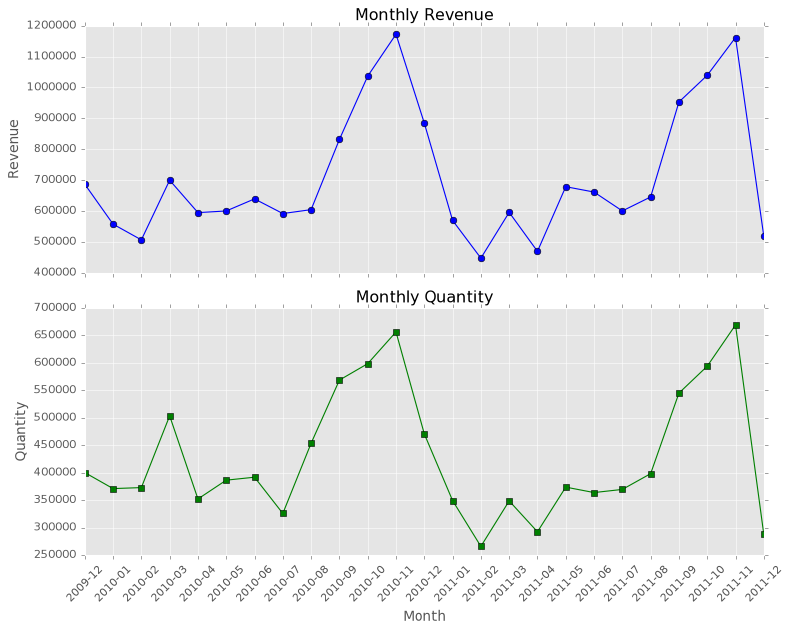

In [61]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

# Revenue
axs[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label='Revenue')
axs[0].set_title('Monthly Revenue')
axs[0].set_ylabel('Revenue')

# Quantity
axs[1].plot(monthly_quantity.index, monthly_quantity.values, marker='s', color='green', label='Quantity')
axs[1].set_title('Monthly Quantity')
axs[1].set_ylabel('Quantity')

plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

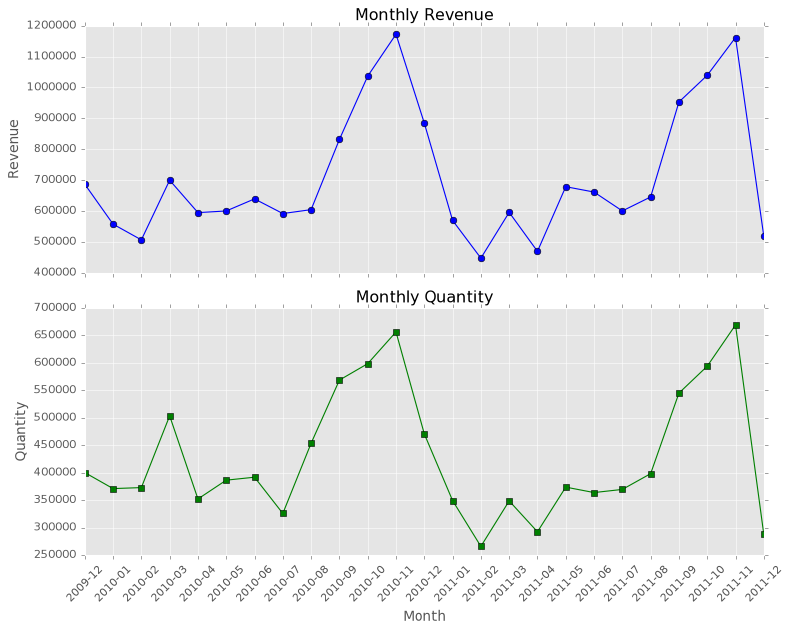

In [62]:
fig

In [63]:
type(fig)

matplotlib.figure.Figure

In [64]:
axs

array([<Axes: title={'center': 'Monthly Revenue'}, ylabel='Revenue'>,
       <Axes: title={'center': 'Monthly Quantity'}, xlabel='Month', ylabel='Quantity'>],
      dtype=object)

In [65]:
type(axs)

numpy.ndarray

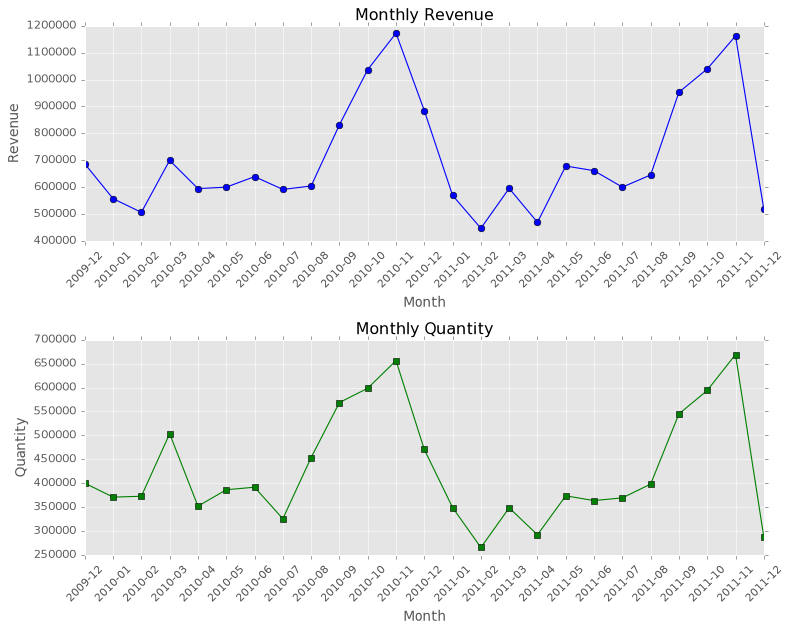

In [66]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=False)

# Revenue
axs[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label='Revenue')
axs[0].set_title('Monthly Revenue')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Revenue')
axs[0].tick_params(axis='x', labelrotation=45)
axs[0].grid(True)

# Quantity
axs[1].plot(monthly_quantity.index, monthly_quantity.values, marker='s', color='green', label='Quantity')
axs[1].set_title('Monthly Quantity')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Quantity')
axs[1].tick_params(axis='x', labelrotation=45)
axs[1].grid(True)

plt.tight_layout()
plt.show()

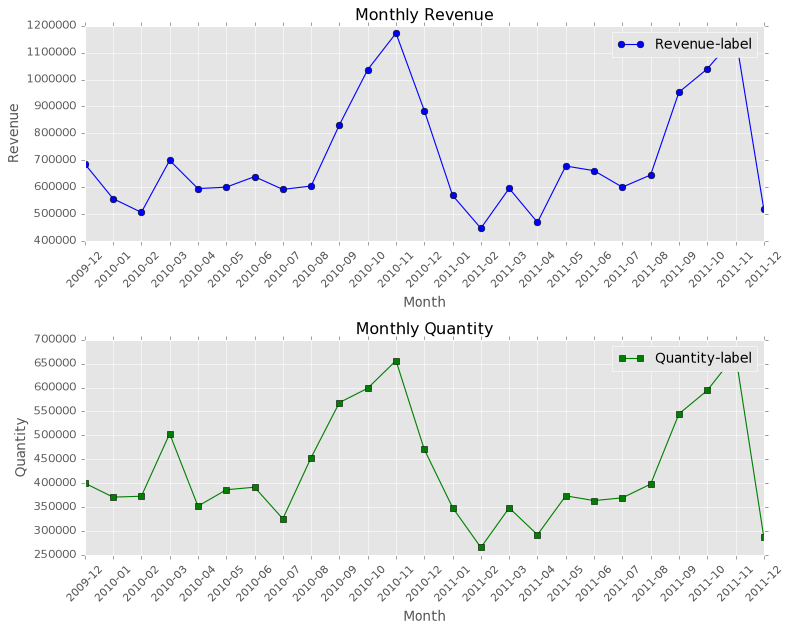

In [67]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=False)

# Revenue
axs[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label='Revenue-label')
axs[0].set_title('Monthly Revenue')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Revenue')
axs[0].tick_params(axis='x', labelrotation=45)
axs[0].legend()
axs[0].grid(True)

# Quantity
axs[1].plot(monthly_quantity.index, monthly_quantity.values, marker='s', color='green', label='Quantity-label')
axs[1].set_title('Monthly Quantity')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Quantity')
axs[1].tick_params(axis='x', labelrotation=45)
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

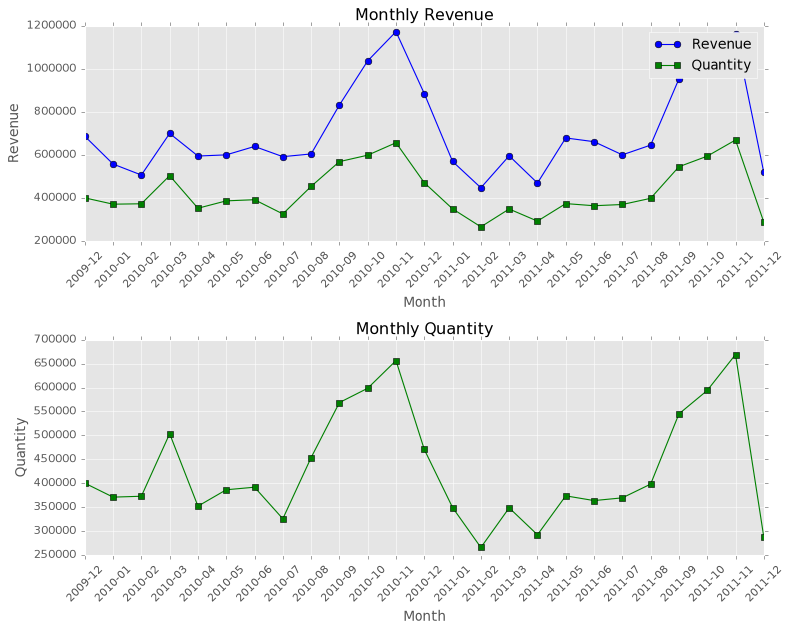

In [68]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=False)

# Revenue
axs[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label='Revenue')
axs[0].plot(monthly_quantity.index, monthly_quantity.values, marker='s', color='green', label='Quantity')
axs[0].set_title('Monthly Revenue')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Revenue')
axs[0].tick_params(axis='x', labelrotation=45)
axs[0].legend()
axs[0].grid(True)

# Quantity
axs[1].plot(monthly_quantity.index, monthly_quantity.values, marker='s', color='green', label='Quantity')
axs[1].set_title('Monthly Quantity')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Quantity')
axs[1].tick_params(axis='x', labelrotation=45)
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Saving & Exporting Figures

In [69]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig('monthly_revenue_plot.png', dpi=300)        # dpi : dots per inch

plt.close()

### Seaborn: High-level Statistical Data Visualization

Seaborn is a powerful Python visualization library built on top of Matplotlib and integrated with Pandas. It simplifies common tasks like:

- Statistical Plots

- Categorical Data Plots

- Distribution Plots

- Color Themes

- Multi-variable Analysis

In [70]:
import seaborn as sns

#### Histogram Plot

In [71]:
# New Analysis : Distribution of Quantity per Transaction
df_quantity = df[(df['Quantity'] > 0) & (df['Quantity'] < 100)]

# 1 - 99

In [72]:
df_quantity.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [73]:
df_quantity['Quantity'].min()

np.int64(1)

In [74]:
df_quantity['Quantity'].max()

np.int64(98)

In [75]:
df_quantity.shape

(792377, 10)

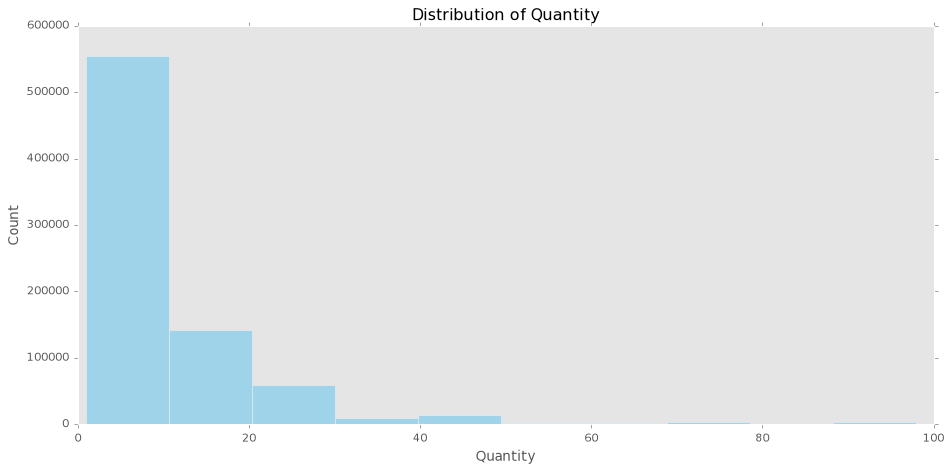

In [76]:
plt.figure(figsize=(12, 6))
sns.histplot(df_quantity['Quantity'], bins=10, kde=False, color='skyblue')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.grid(False)
plt.tight_layout()
plt.show()

Show me how transaction quantities (between 1 and 99) are distributed. Bin them into 10 groups, but also draw a smooth probability curve showing where quantity values tend to cluster.

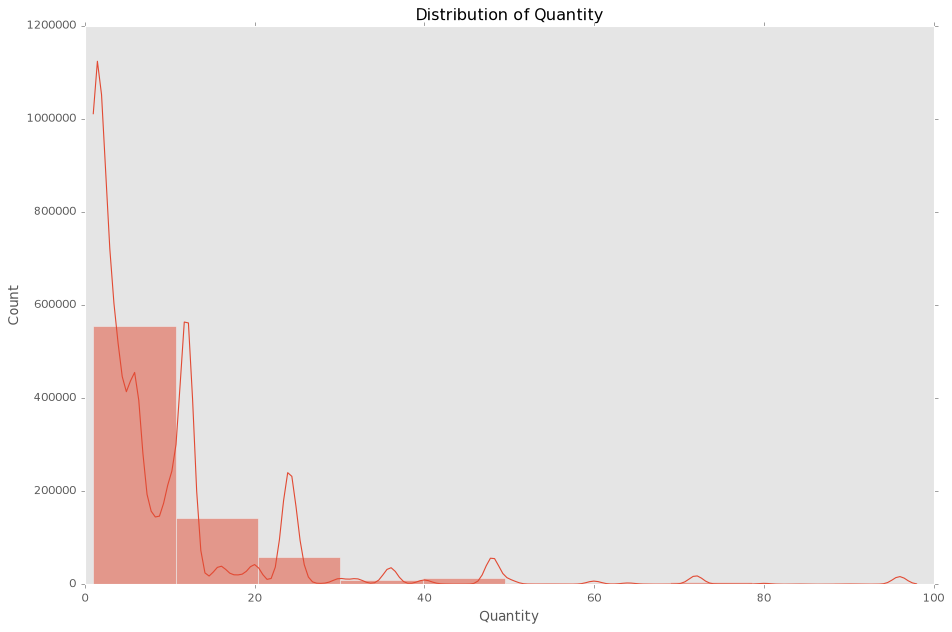

In [77]:
plt.figure(figsize=(12, 8))
sns.histplot(df_quantity['Quantity'], bins=10, kde=True)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.grid(False)
plt.tight_layout()
plt.show()

# kde : Kernel Density Estimate

#### KDE Plot

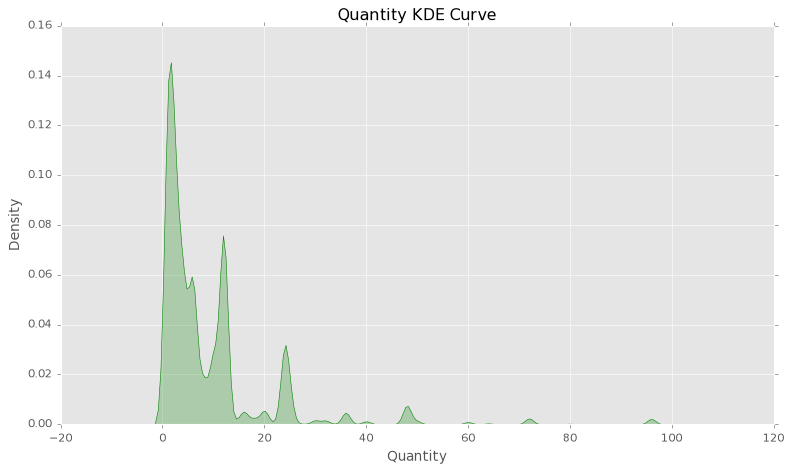

In [78]:
# sns.kdeplot() - KDE smooth version of histogram

plt.figure(figsize=(10, 6))
sns.kdeplot(df_quantity['Quantity'], fill=True, color='green')
plt.title('Quantity KDE Curve')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()

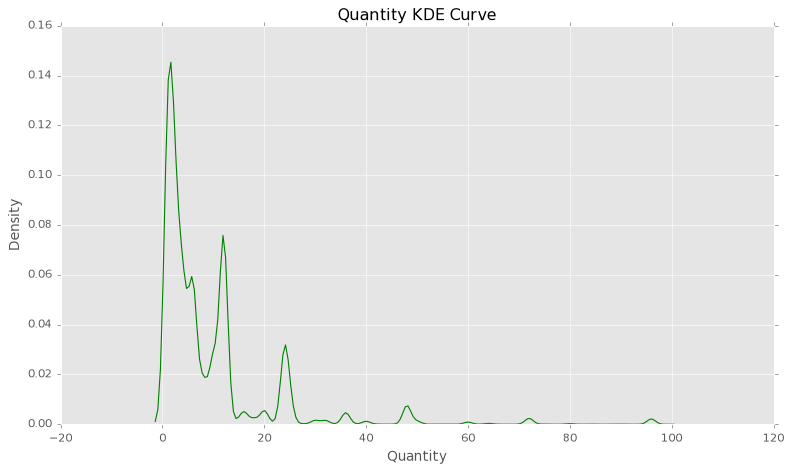

In [79]:
# sns.kdeplot() - KDE smooth version of histogram

plt.figure(figsize=(10, 6))
sns.kdeplot(df_quantity['Quantity'], color='green')
plt.title('Quantity KDE Curve')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()

In [80]:
df_sample = df[['Quantity', 'Price', 'Revenue', 'Country', 'Month']].copy()

In [81]:
df_sample.head()

,Quantity,Price,Revenue,Country,Month
0,12,6.95,83.4,United Kingdom,2009-12
1,12,6.75,81.0,United Kingdom,2009-12
2,12,6.75,81.0,United Kingdom,2009-12
3,48,2.10,100.8,United Kingdom,2009-12
4,24,1.25,30.0,United Kingdom,2009-12


In [82]:
df_sample.shape

(805549, 5)

#### Box Plot

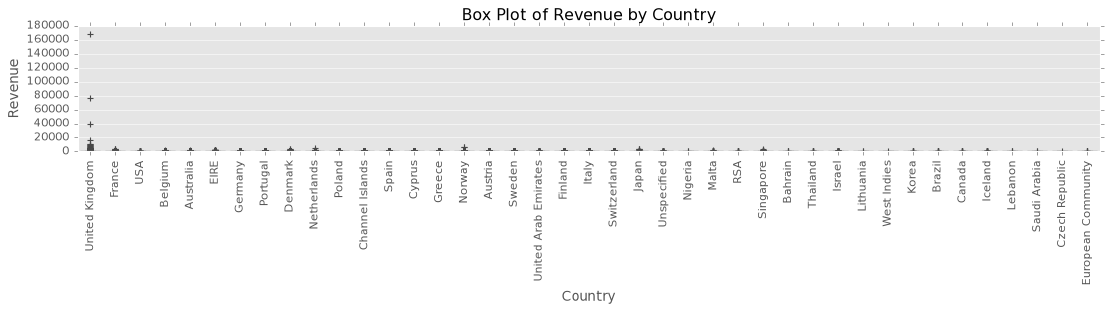

In [83]:
# sns.boxplot() - Distribution + Outlier Visualization

plt.figure(figsize=(14, 4))
sns.boxplot(data=df_sample, x='Country', y='Revenue')
plt.xticks(rotation=90)
plt.title('Box Plot of Revenue by Country')
plt.tight_layout()
plt.show()

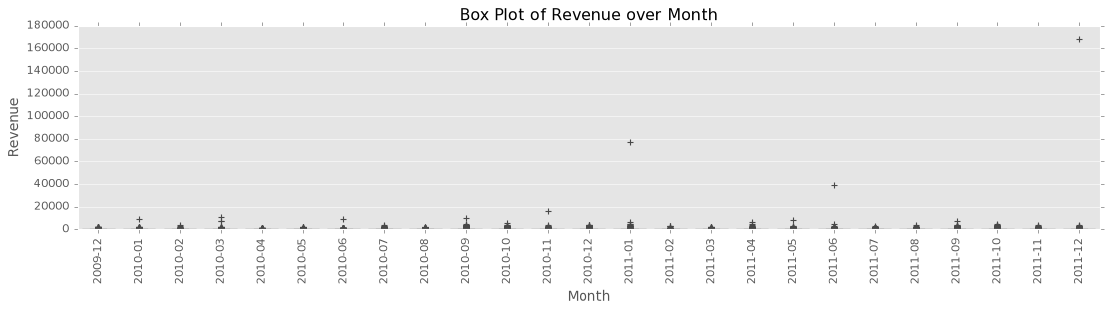

In [84]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df_sample, x='Month', y='Revenue')
plt.xticks(rotation=90)
plt.title('Box Plot of Revenue over Month')
plt.tight_layout()
plt.show()

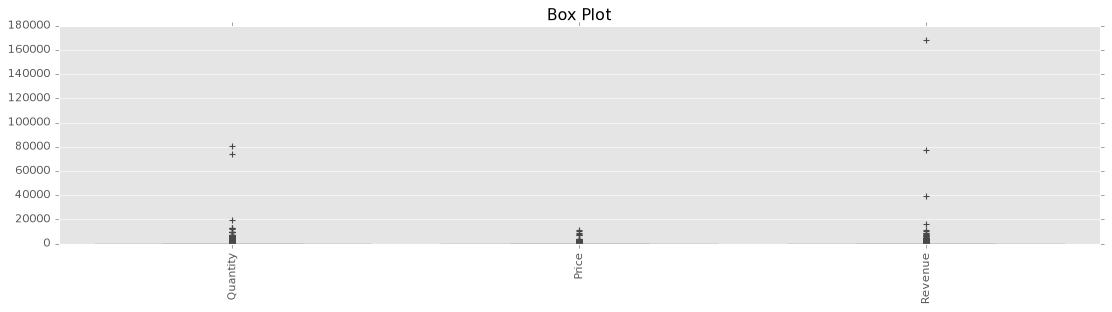

In [85]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df_sample)
plt.xticks(rotation=90)
plt.title('Box Plot')
plt.tight_layout()
plt.show()

In [86]:
df_revenue_sample = df[(df['Revenue'] > 1000) & (df['Revenue'] < 2000)]

In [87]:
df_revenue_sample.shape

(463, 10)

In [88]:
df_revenue_sample.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
575,489523,84879,ASSORTED COLOUR BIRD ORNAMENT,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom,1160.0,2009-12
3290,489675,15056BL,EDWARDIAN PARASOL BLACK,240,2009-12-02 09:47:00,4.60,13777.0,United Kingdom,1104.0,2009-12
4793,489831,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-02 13:58:00,2.10,12435.0,Denmark,1008.0,2009-12
6443,489889,85123A,WHITE HANGING HEART T-LIGHT HOLDER,480,2009-12-02 16:52:00,2.55,14646.0,Netherlands,1224.0,2009-12
7007,490010,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-03 12:15:00,2.10,15061.0,United Kingdom,1008.0,2009-12


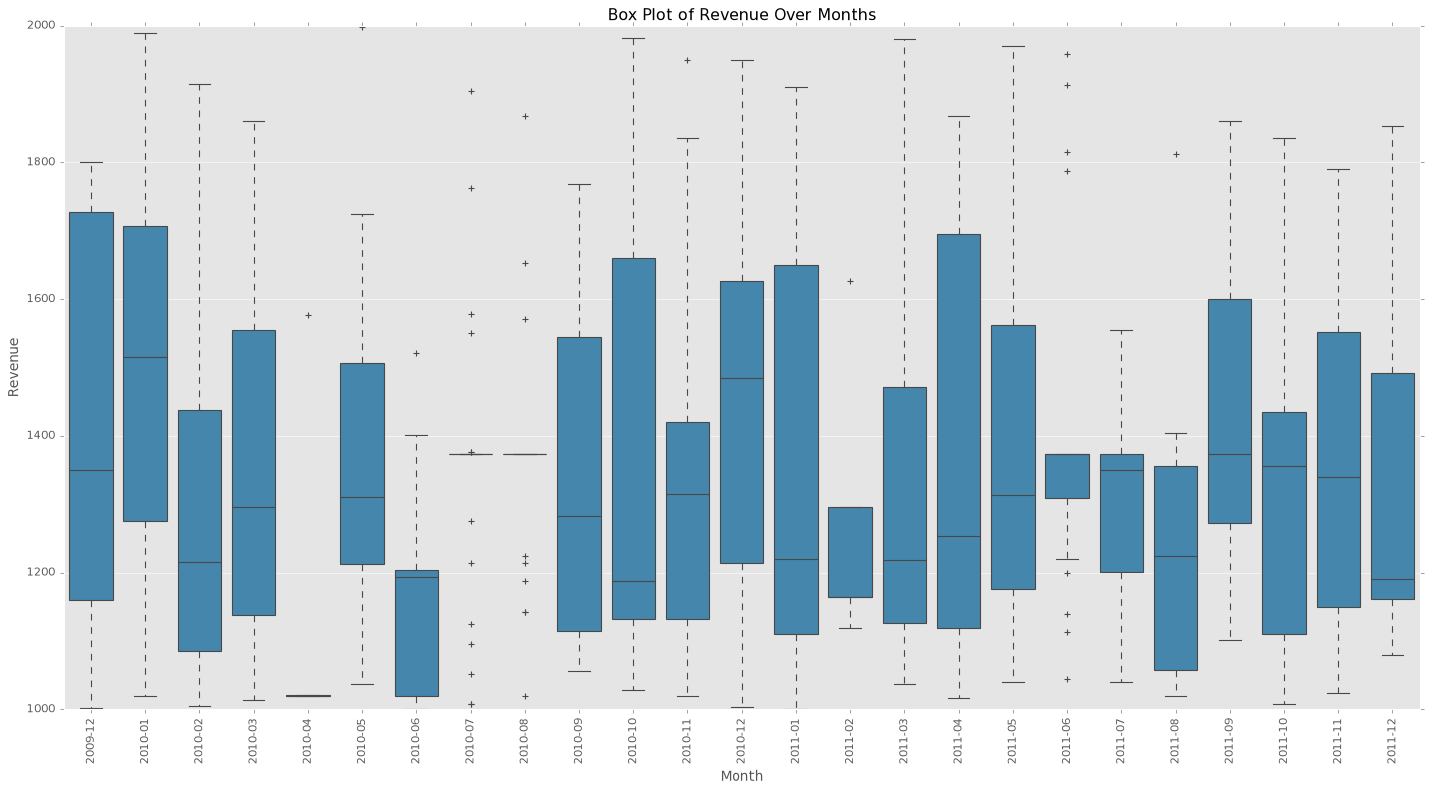

In [89]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=df_revenue_sample, x='Month', y='Revenue')
plt.xticks(rotation=90)
plt.title('Box Plot of Revenue Over Months')
plt.tight_layout()
plt.show()

### Categorical Data Visualization

In [90]:
# 1. Top Countries by Revenue (Bar Plot)

top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

/var/folders/zb/n9nlvsbd4jj_mcdqw7lg_7kw0000gn/T/ipykernel_4142/3104011613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


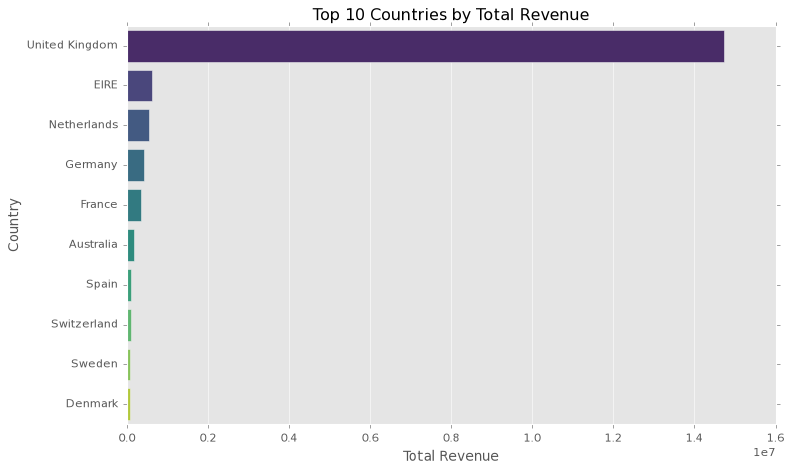

In [91]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

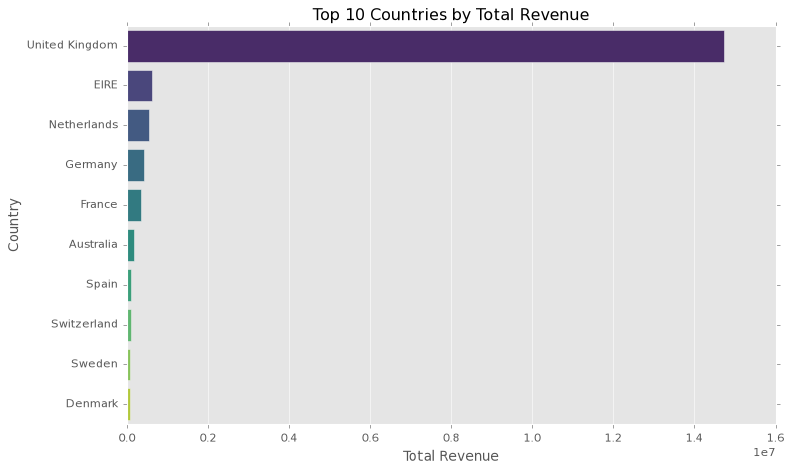

In [92]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, legend=False, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

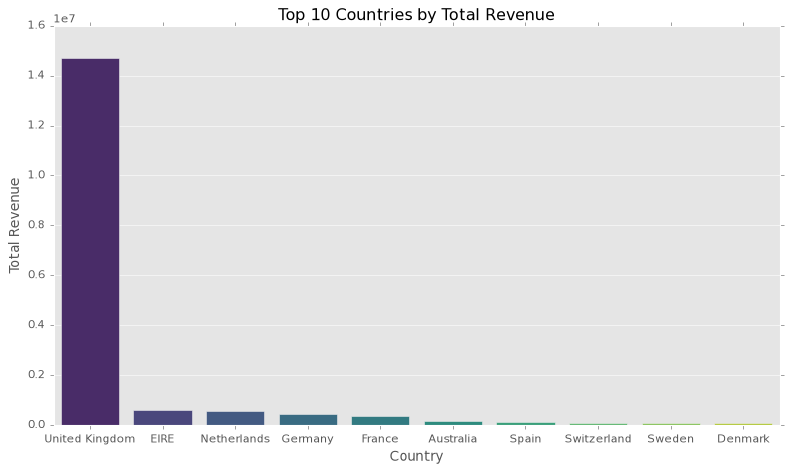

In [93]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, legend=False, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

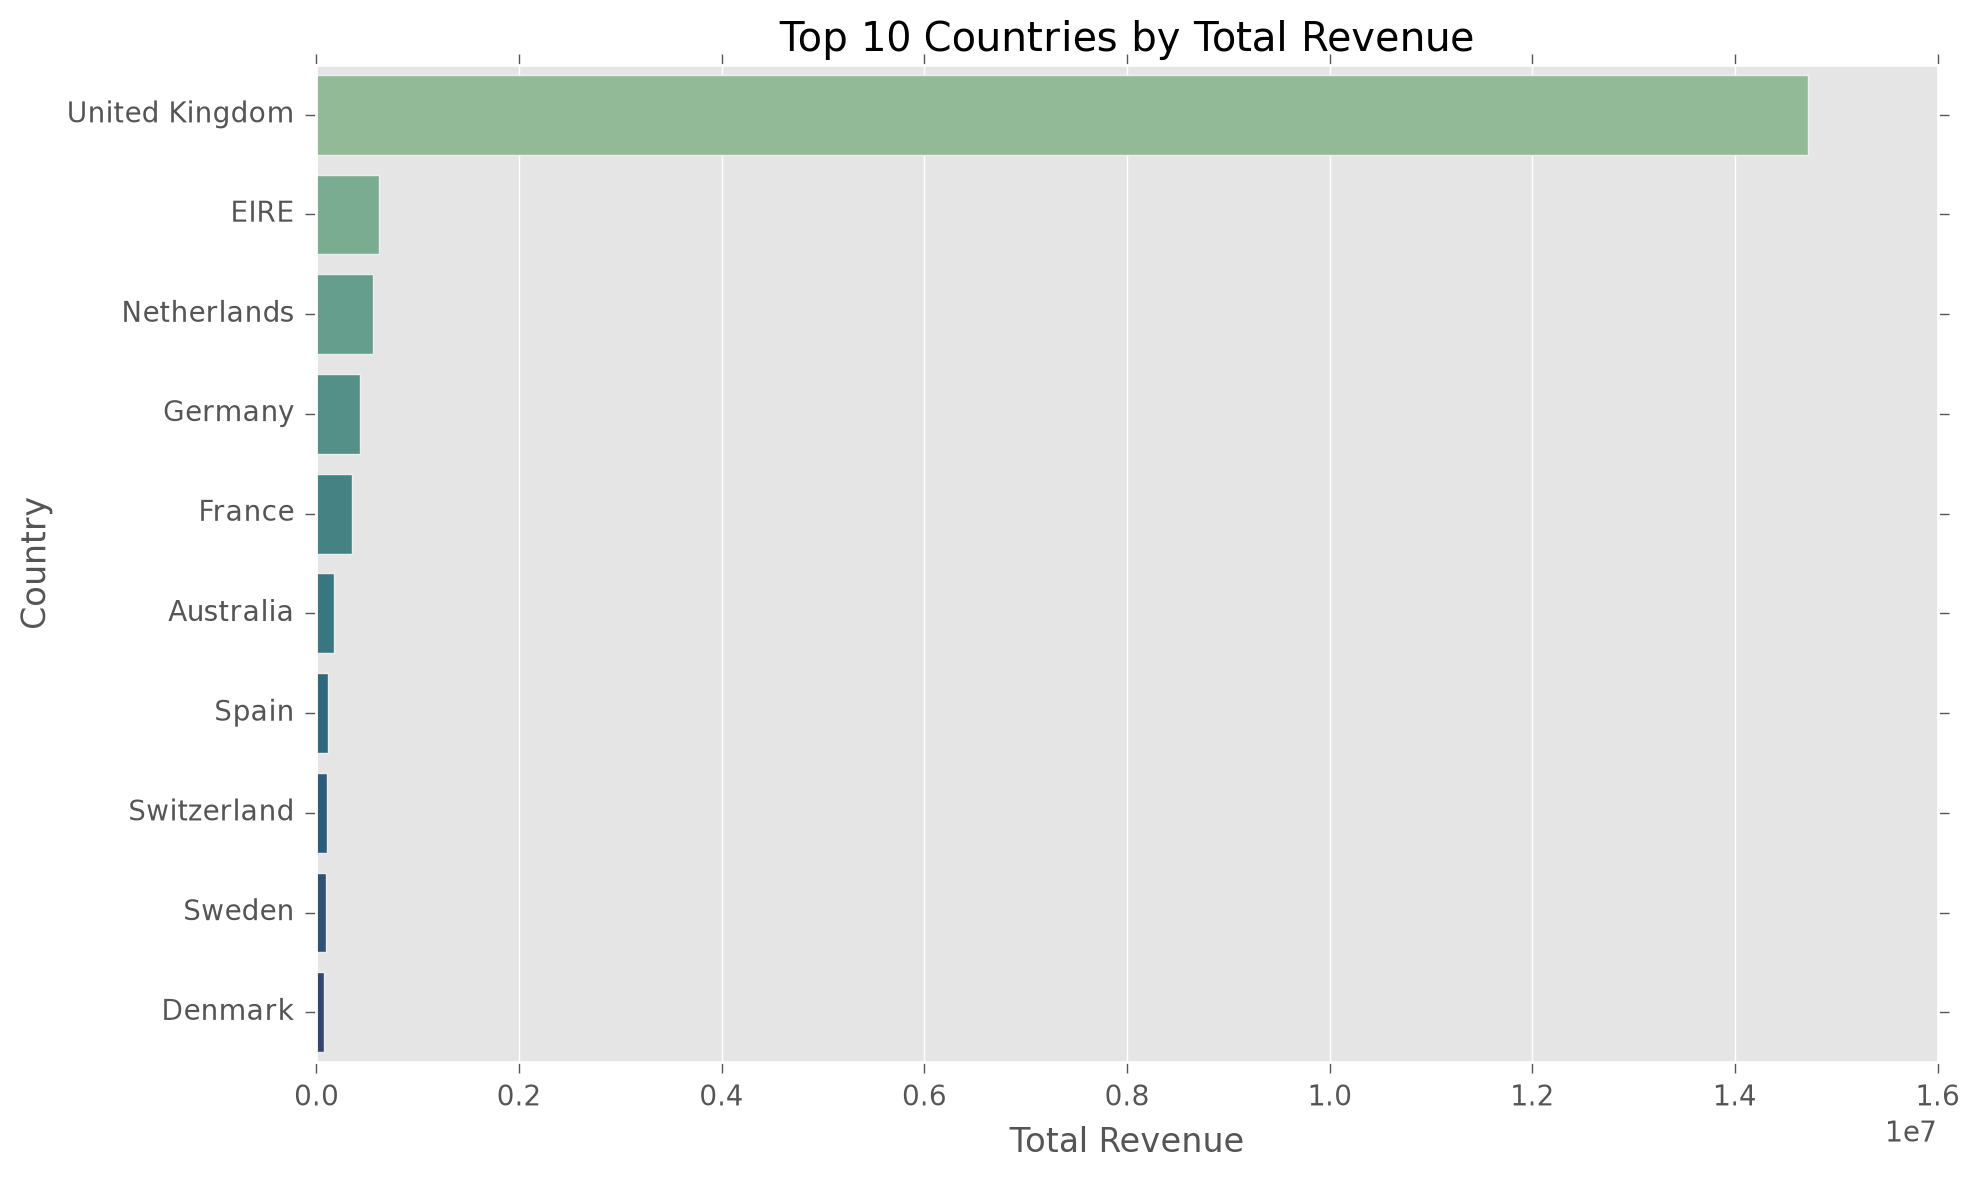

In [94]:
plt.figure(figsize=(10, 6), dpi=200)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, legend=False, palette='crest')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

#### Count Plot

In [95]:
# 2. Number of Transactions by Country (Count Plot)

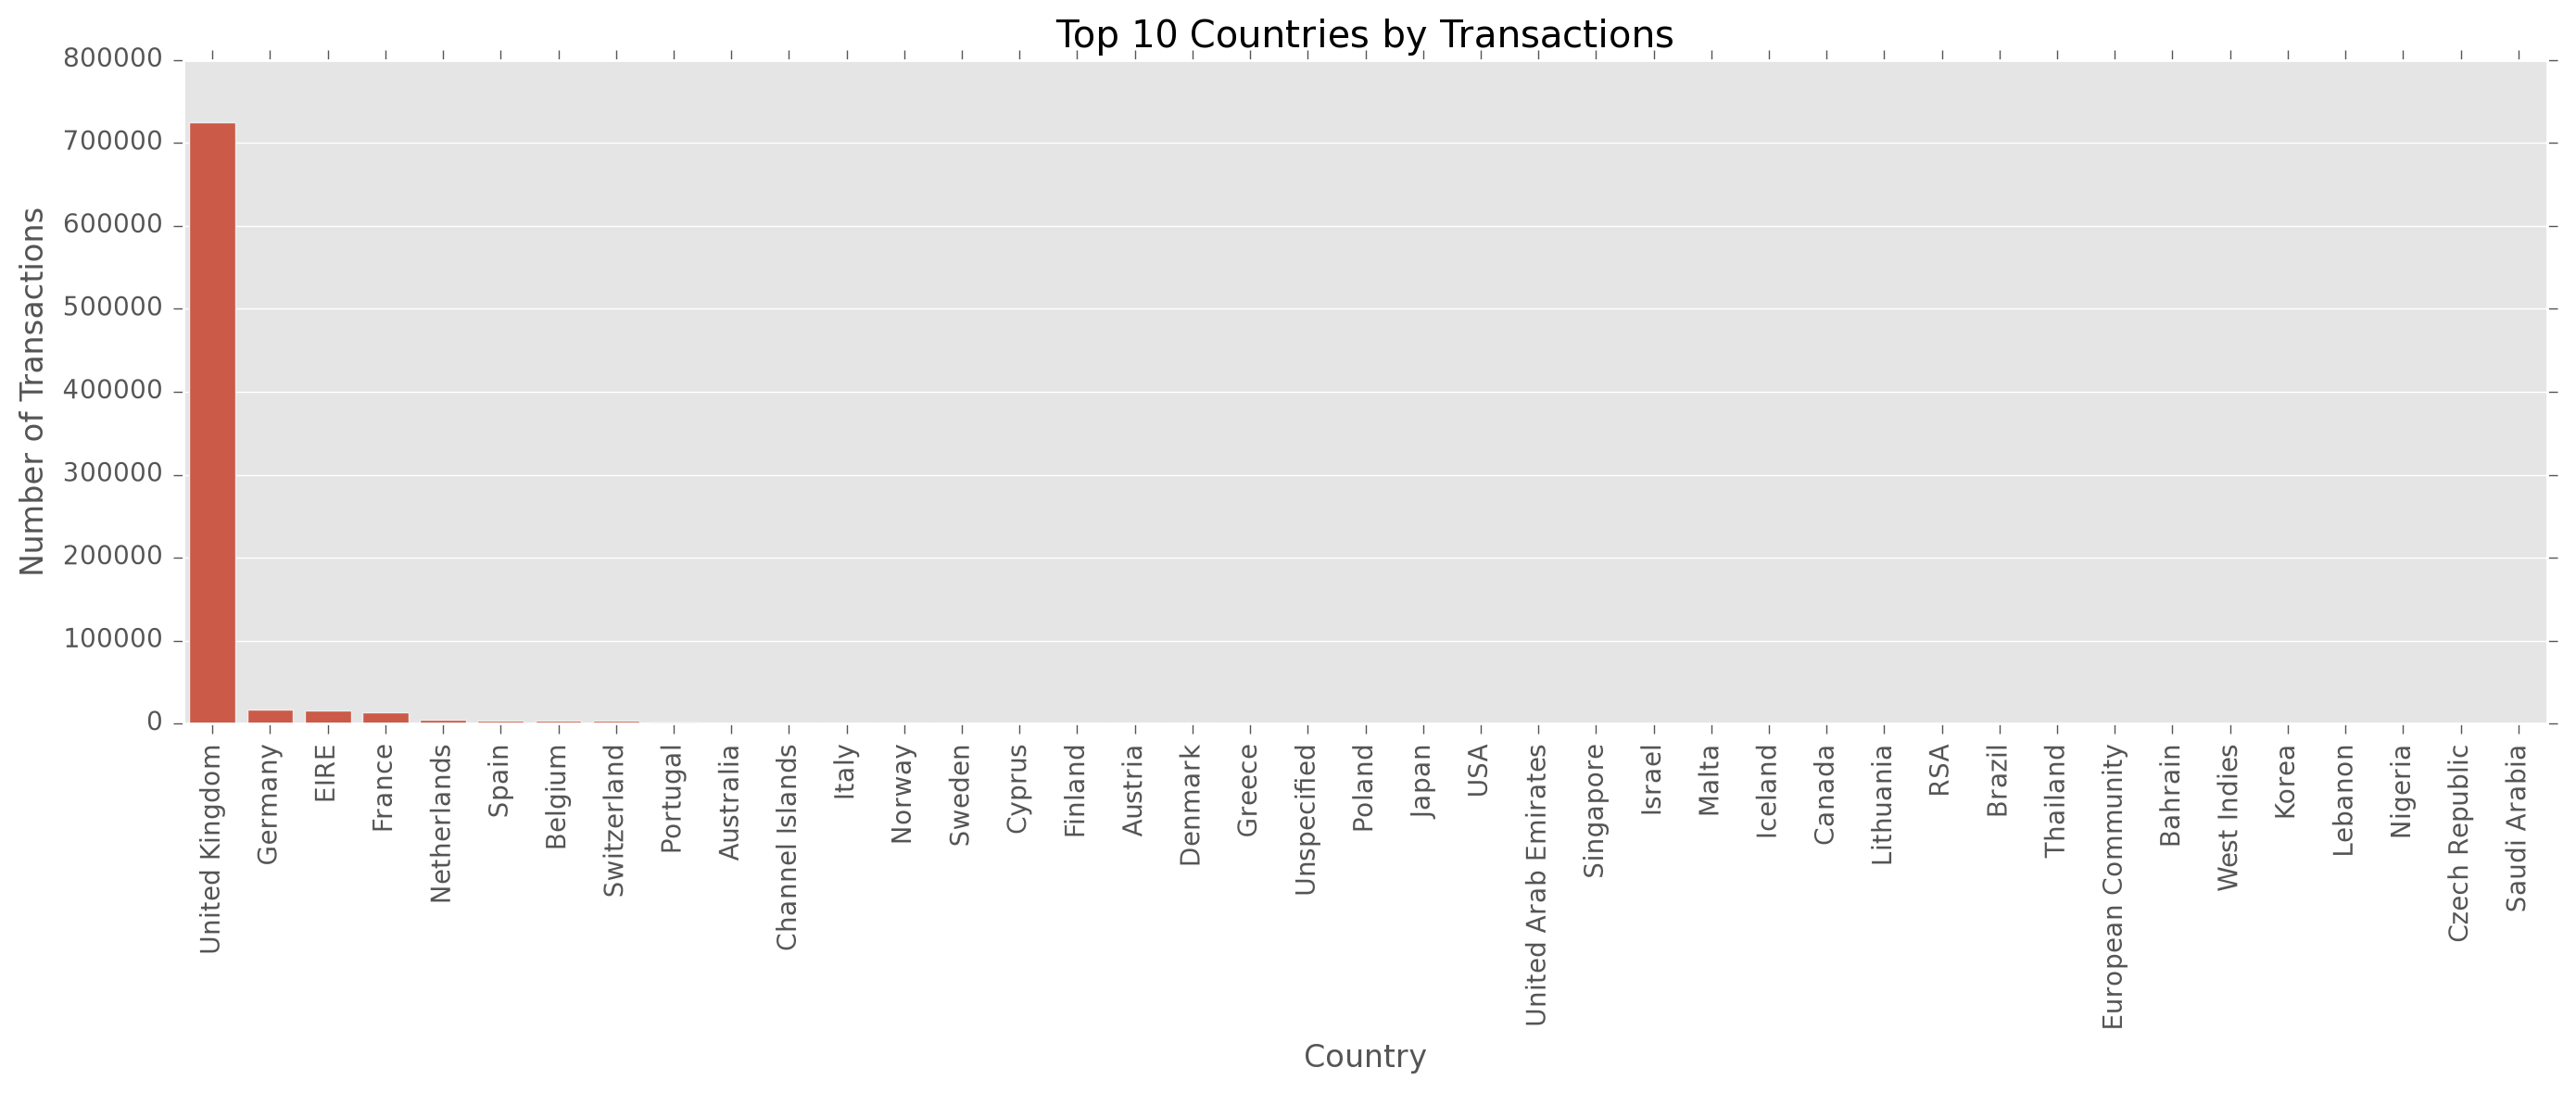

In [96]:
plt.figure(figsize=(14, 6), dpi=200)
sns.countplot(data=df_sample, x=df_sample['Country'], order=df_sample['Country'].value_counts().index)
plt.title('Top 10 Countries by Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [97]:
# 3. Top 5 Countries by Number of Transactions

In [98]:
transactions_per_country = df['Country'].value_counts().head(5)
transactions_per_country

Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Name: count, dtype: int64

In [99]:
df.groupby('Country')['Invoice'].nunique().sort_values(ascending=False).head(5)
# Returns the count of unique invoices per Country (top 5 only)

Country
United Kingdom    33541
Germany             789
France              614
EIRE                567
Netherlands         228
Name: Invoice, dtype: int64

In [100]:
# top 5 countries --> by number of rows present

# filter only the rows that have these 5 countries

# Group by Country & Month

In [101]:
top_5_countries = df['Country'].value_counts().head(5).index.to_list()
print(top_5_countries)

df_top = df[df['Country'].isin(top_5_countries)].copy()
# print(df_top)

grouped = df_top.groupby(['Country', 'Month'])['Revenue'].sum().reset_index()

['United Kingdom', 'Germany', 'EIRE', 'France', 'Netherlands']


In [102]:
grouped.head()

,Country,Month,Revenue
0,EIRE,2009-12,18170.46
1,EIRE,2010-01,65031.41
2,EIRE,2010-02,20206.46
3,EIRE,2010-03,22989.46
4,EIRE,2010-04,20668.08


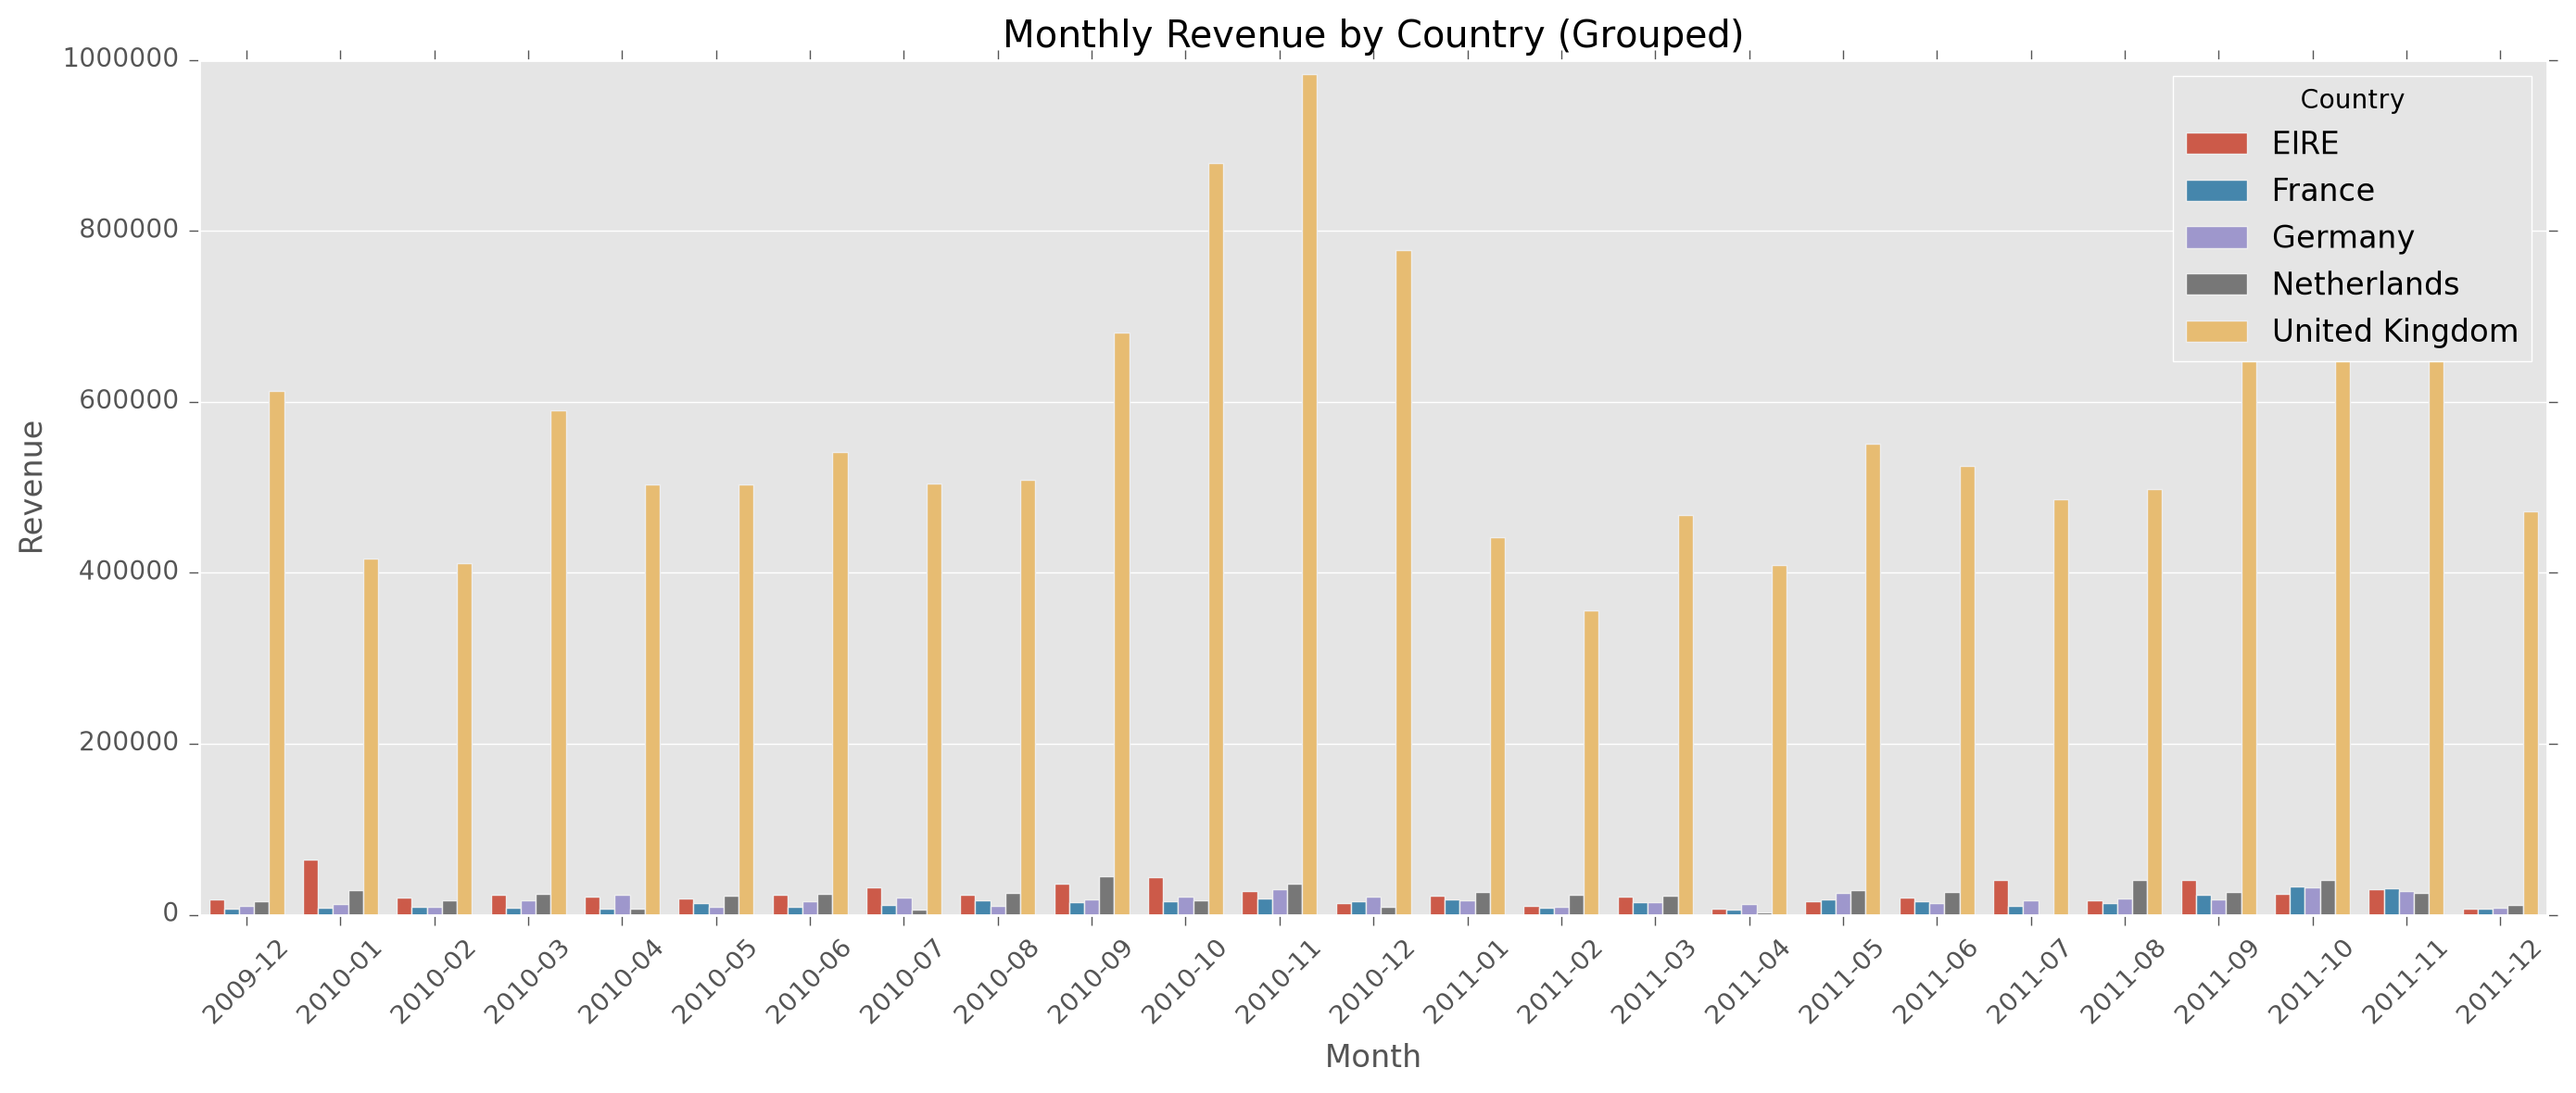

In [103]:
# 1. Grouped Bar Plot Using Seaborn

plt.figure(figsize=(14, 6), dpi=200)
sns.barplot(data=grouped, x='Month', y='Revenue', hue='Country')
plt.title('Monthly Revenue by Country (Grouped)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Country')
plt.show()

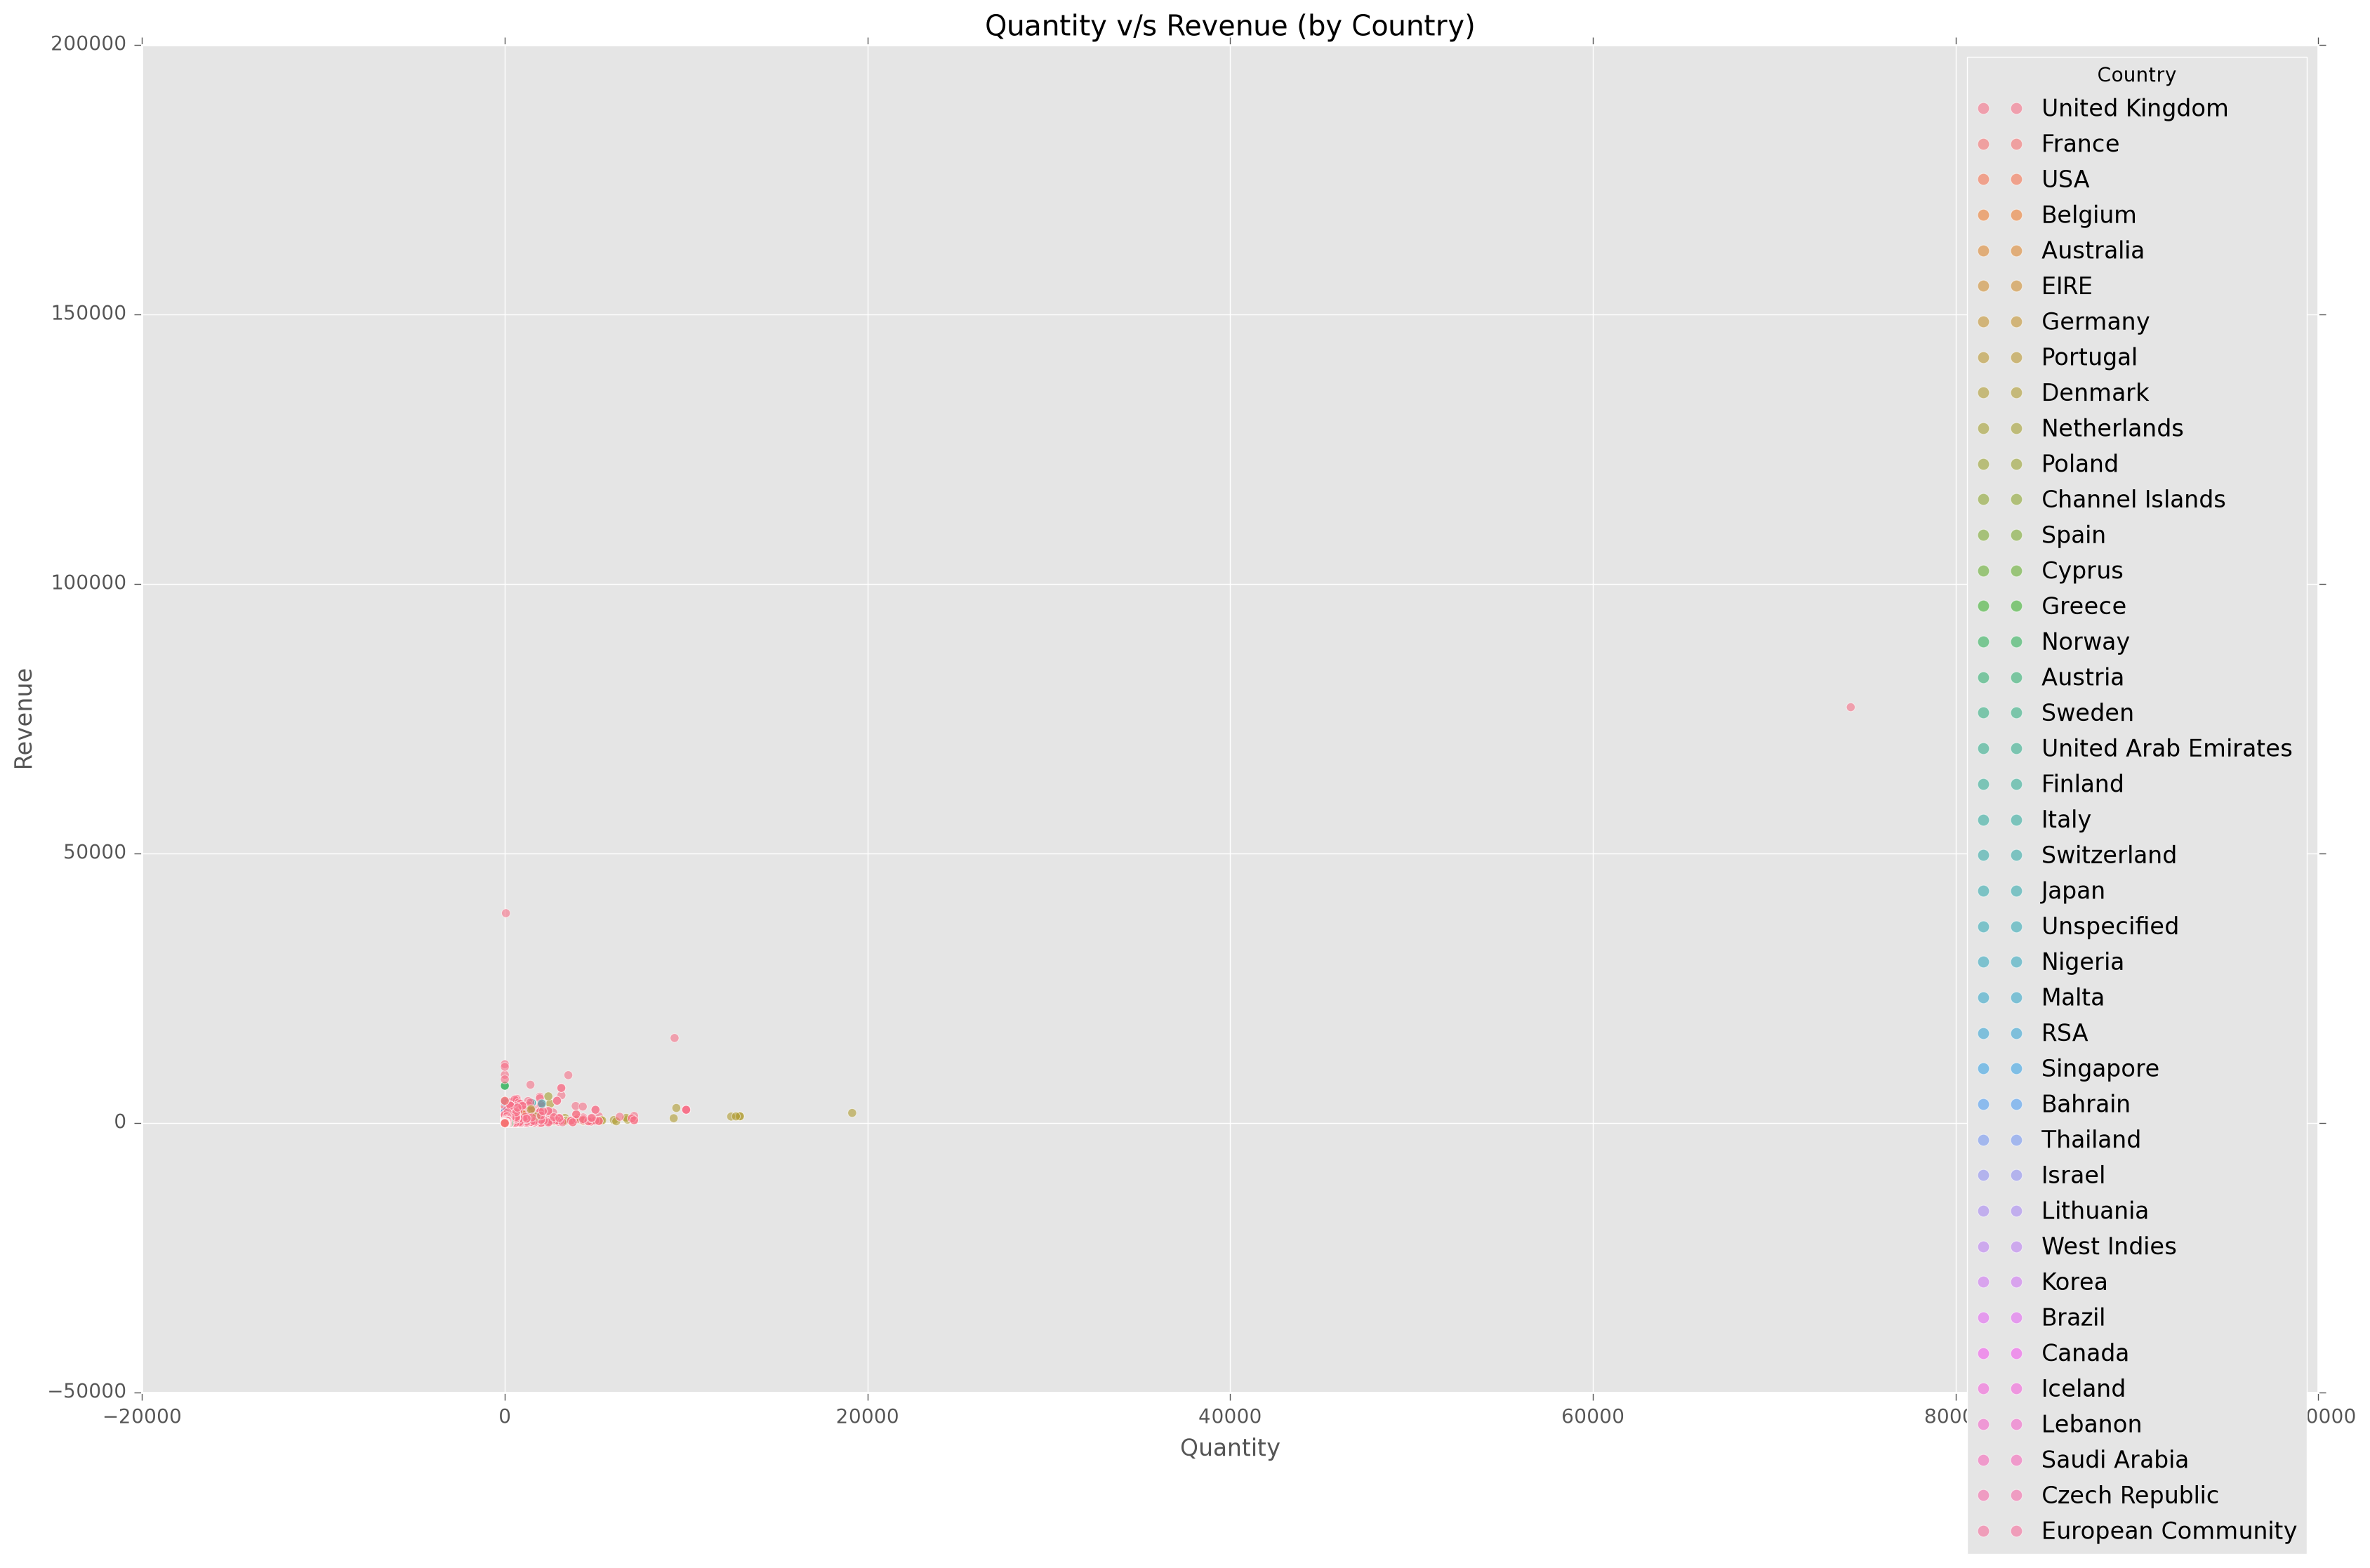

In [104]:
plt.figure(figsize=(20, 12), dpi=200)
sns.scatterplot(data=df_sample, x='Quantity', y='Revenue', hue='Country', alpha=0.6)
plt.title('Quantity v/s Revenue (by Country)')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()

In [105]:
df_filtered = df_sample[(df_sample['Quantity'] > 0) &
                        (df_sample['Quantity'] < 5000) &
                        (df_sample['Revenue'] > 0) &
                        (df_sample['Revenue'] < 10000)]

In [106]:
df_filtered.shape

(805514, 5)

In [107]:
df_filtered.head()

,Quantity,Price,Revenue,Country,Month
0,12,6.95,83.4,United Kingdom,2009-12
1,12,6.75,81.0,United Kingdom,2009-12
2,12,6.75,81.0,United Kingdom,2009-12
3,48,2.10,100.8,United Kingdom,2009-12
4,24,1.25,30.0,United Kingdom,2009-12


In [108]:
top_5_countries = df_filtered['Country'].value_counts().head(5).index
df_filtered = df_filtered[df_filtered['Country'].isin(top_5_countries)]

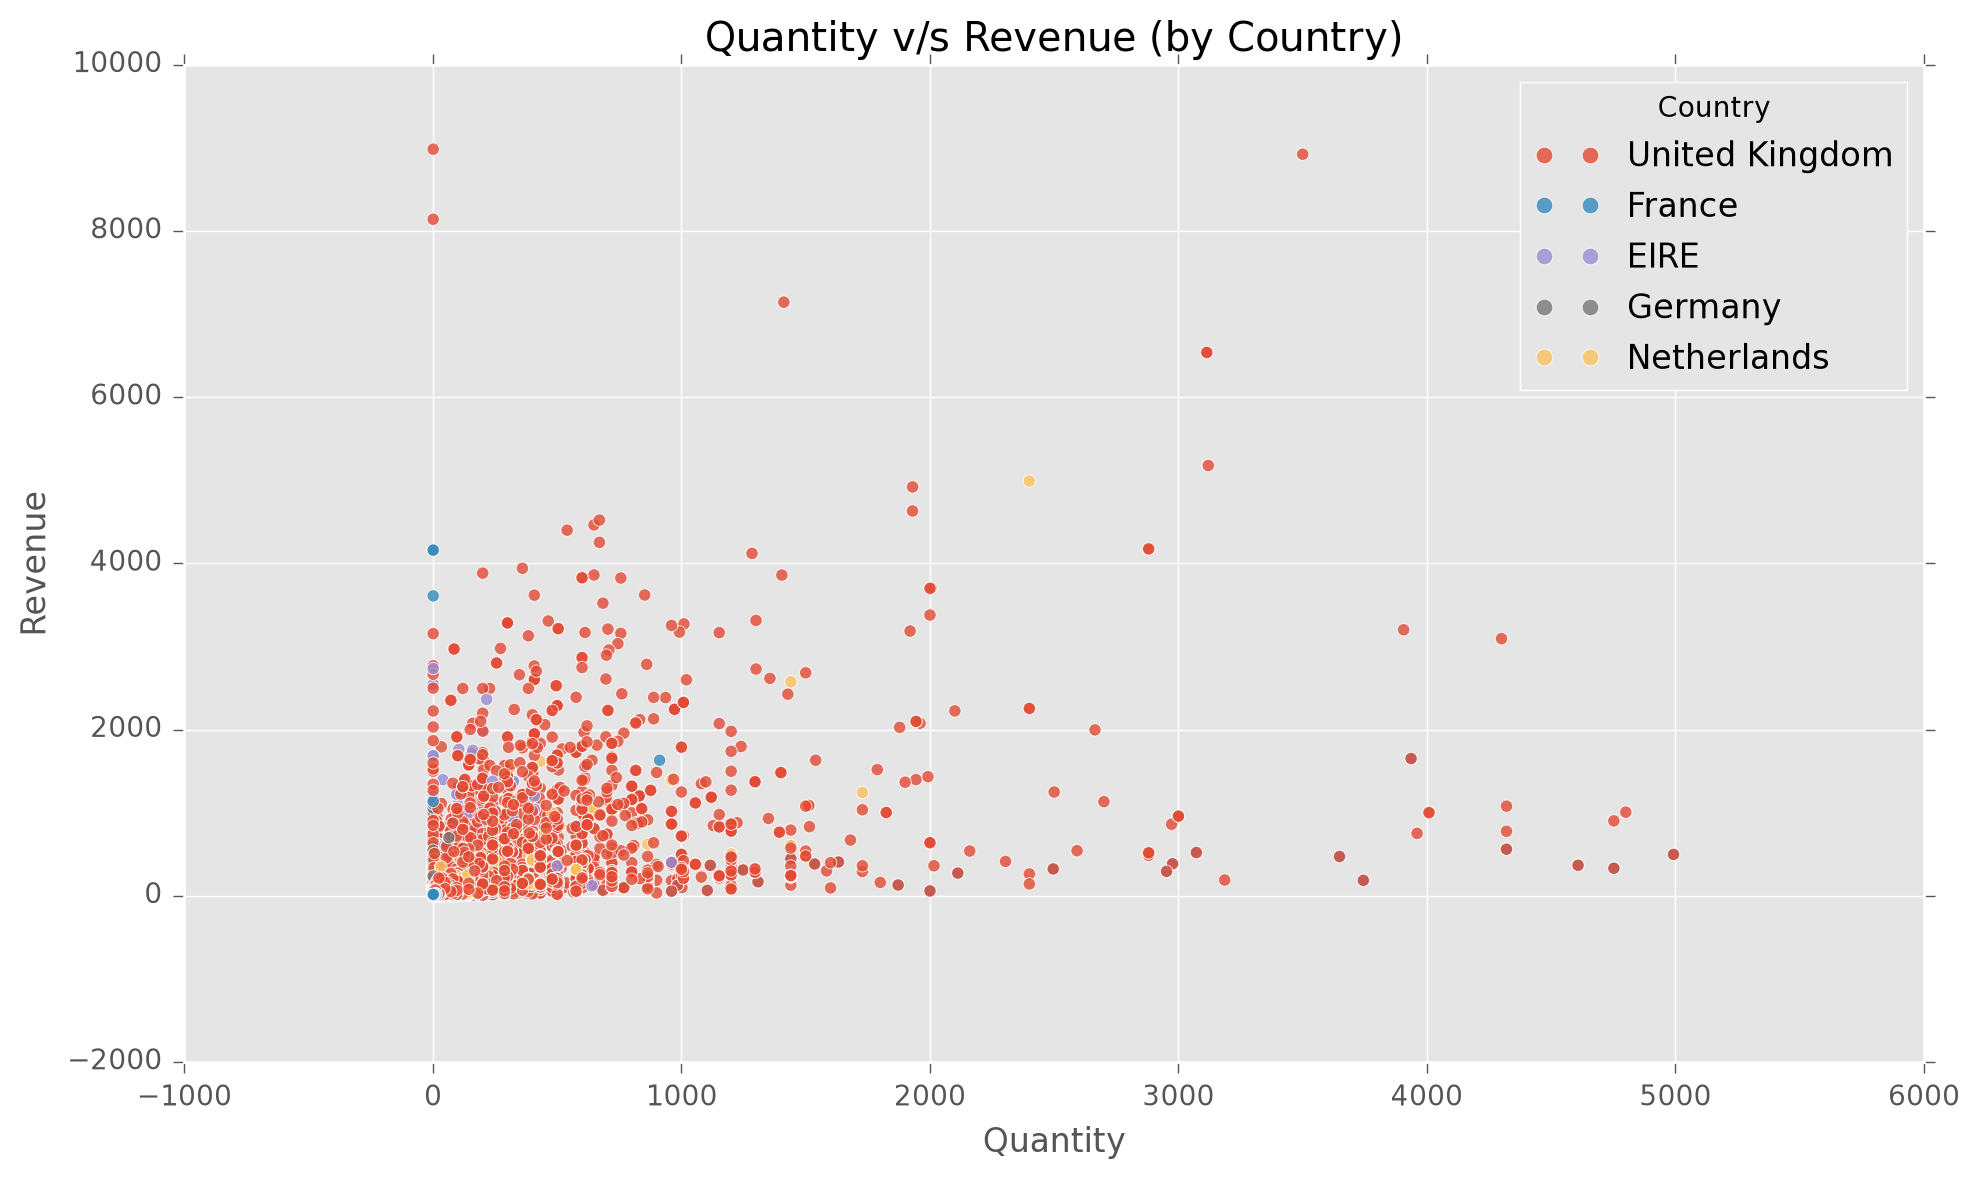

In [109]:
plt.figure(figsize=(10, 6), dpi=200)
sns.scatterplot(data=df_filtered, x='Quantity', y='Revenue', hue='Country', alpha=0.8)
plt.title('Quantity v/s Revenue (by Country)')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

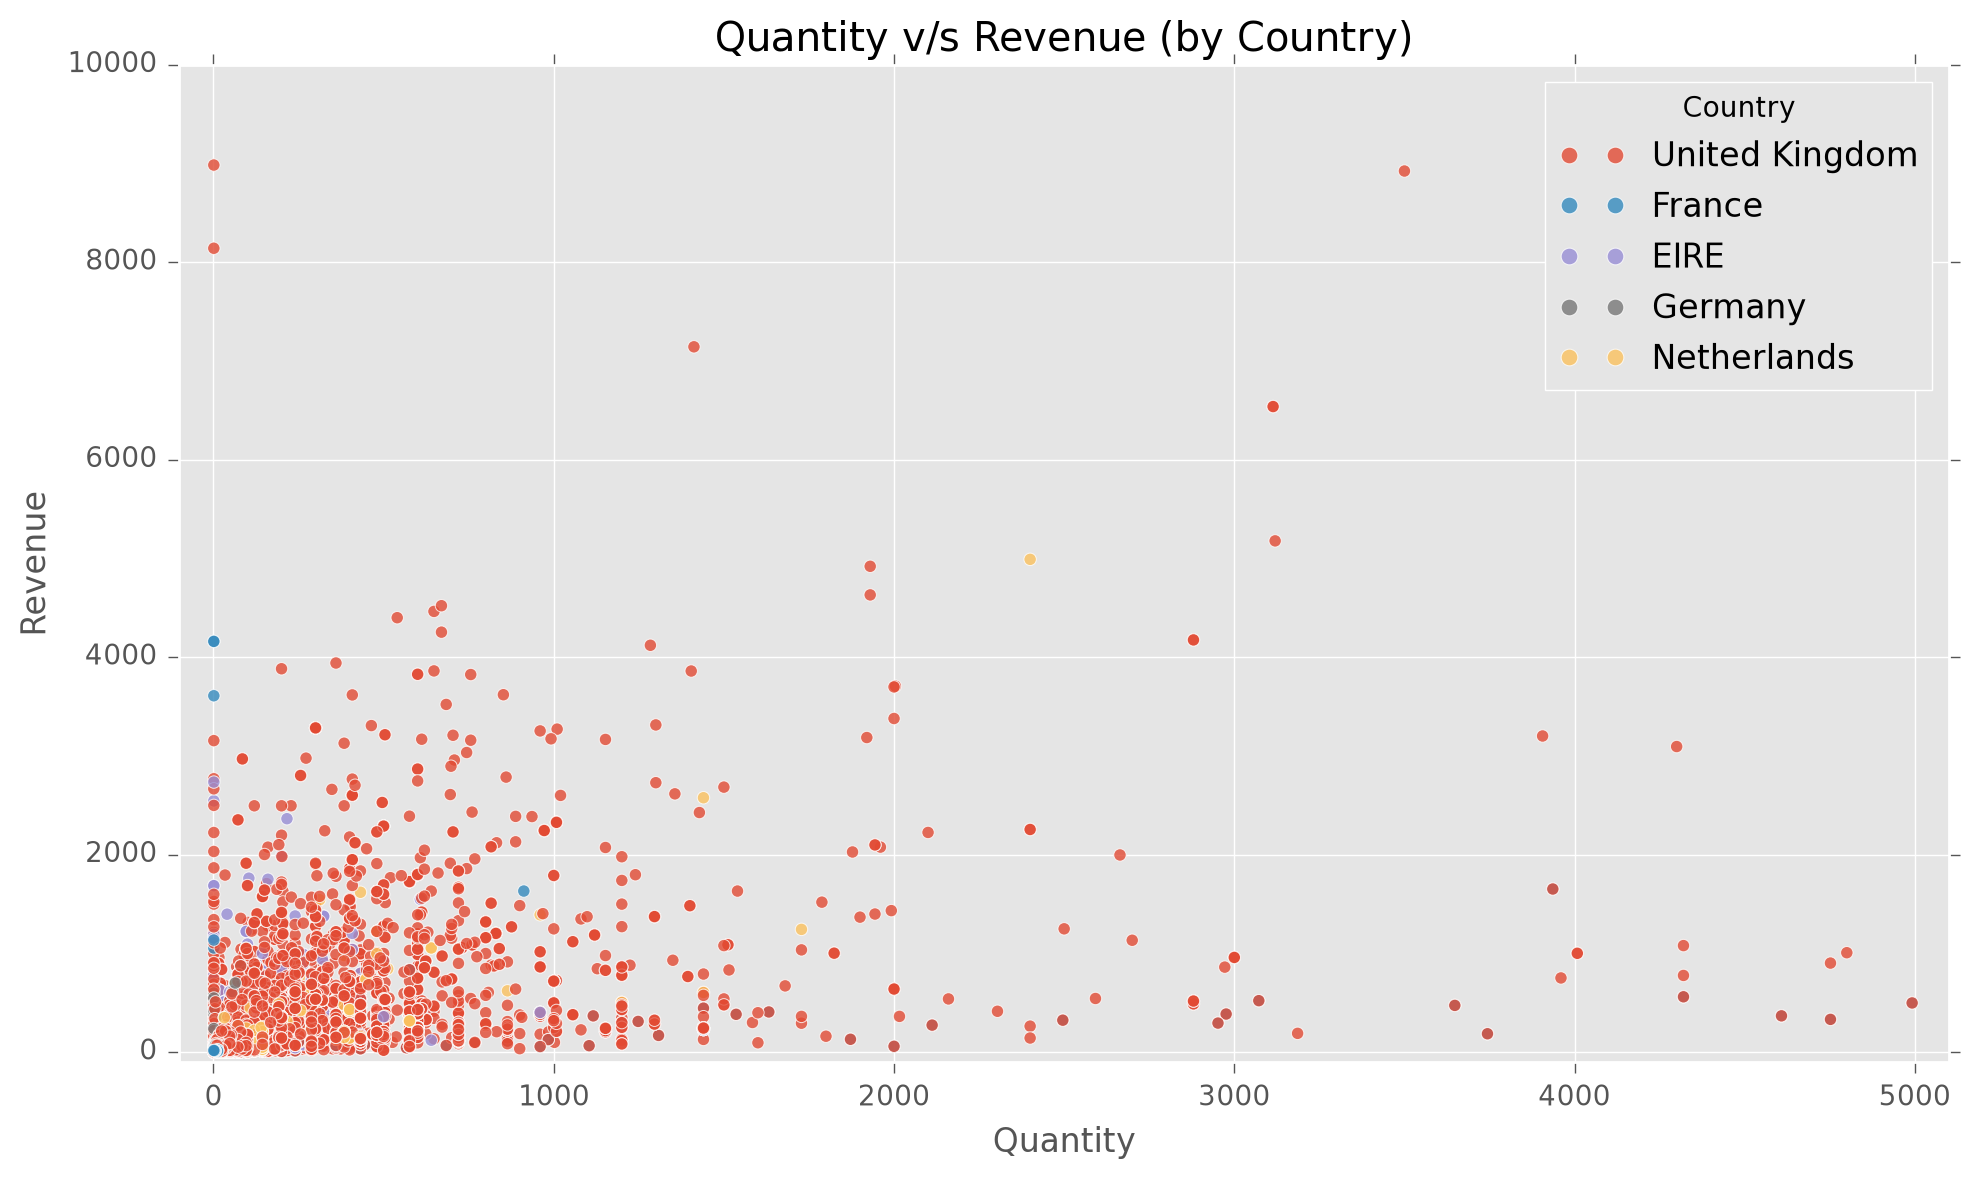

In [110]:
plt.figure(figsize=(10, 6), dpi=200)
sns.scatterplot(data=df_filtered, x='Quantity', y='Revenue', hue='Country', alpha=0.8)
plt.title('Quantity v/s Revenue (by Country)')
plt.xlabel('Quantity')
plt.ylabel('Revenue')

plt.xlim(-100, 5100)
plt.ylim(-100, 10000)

plt.tight_layout()
plt.show()

#### Pair Plot

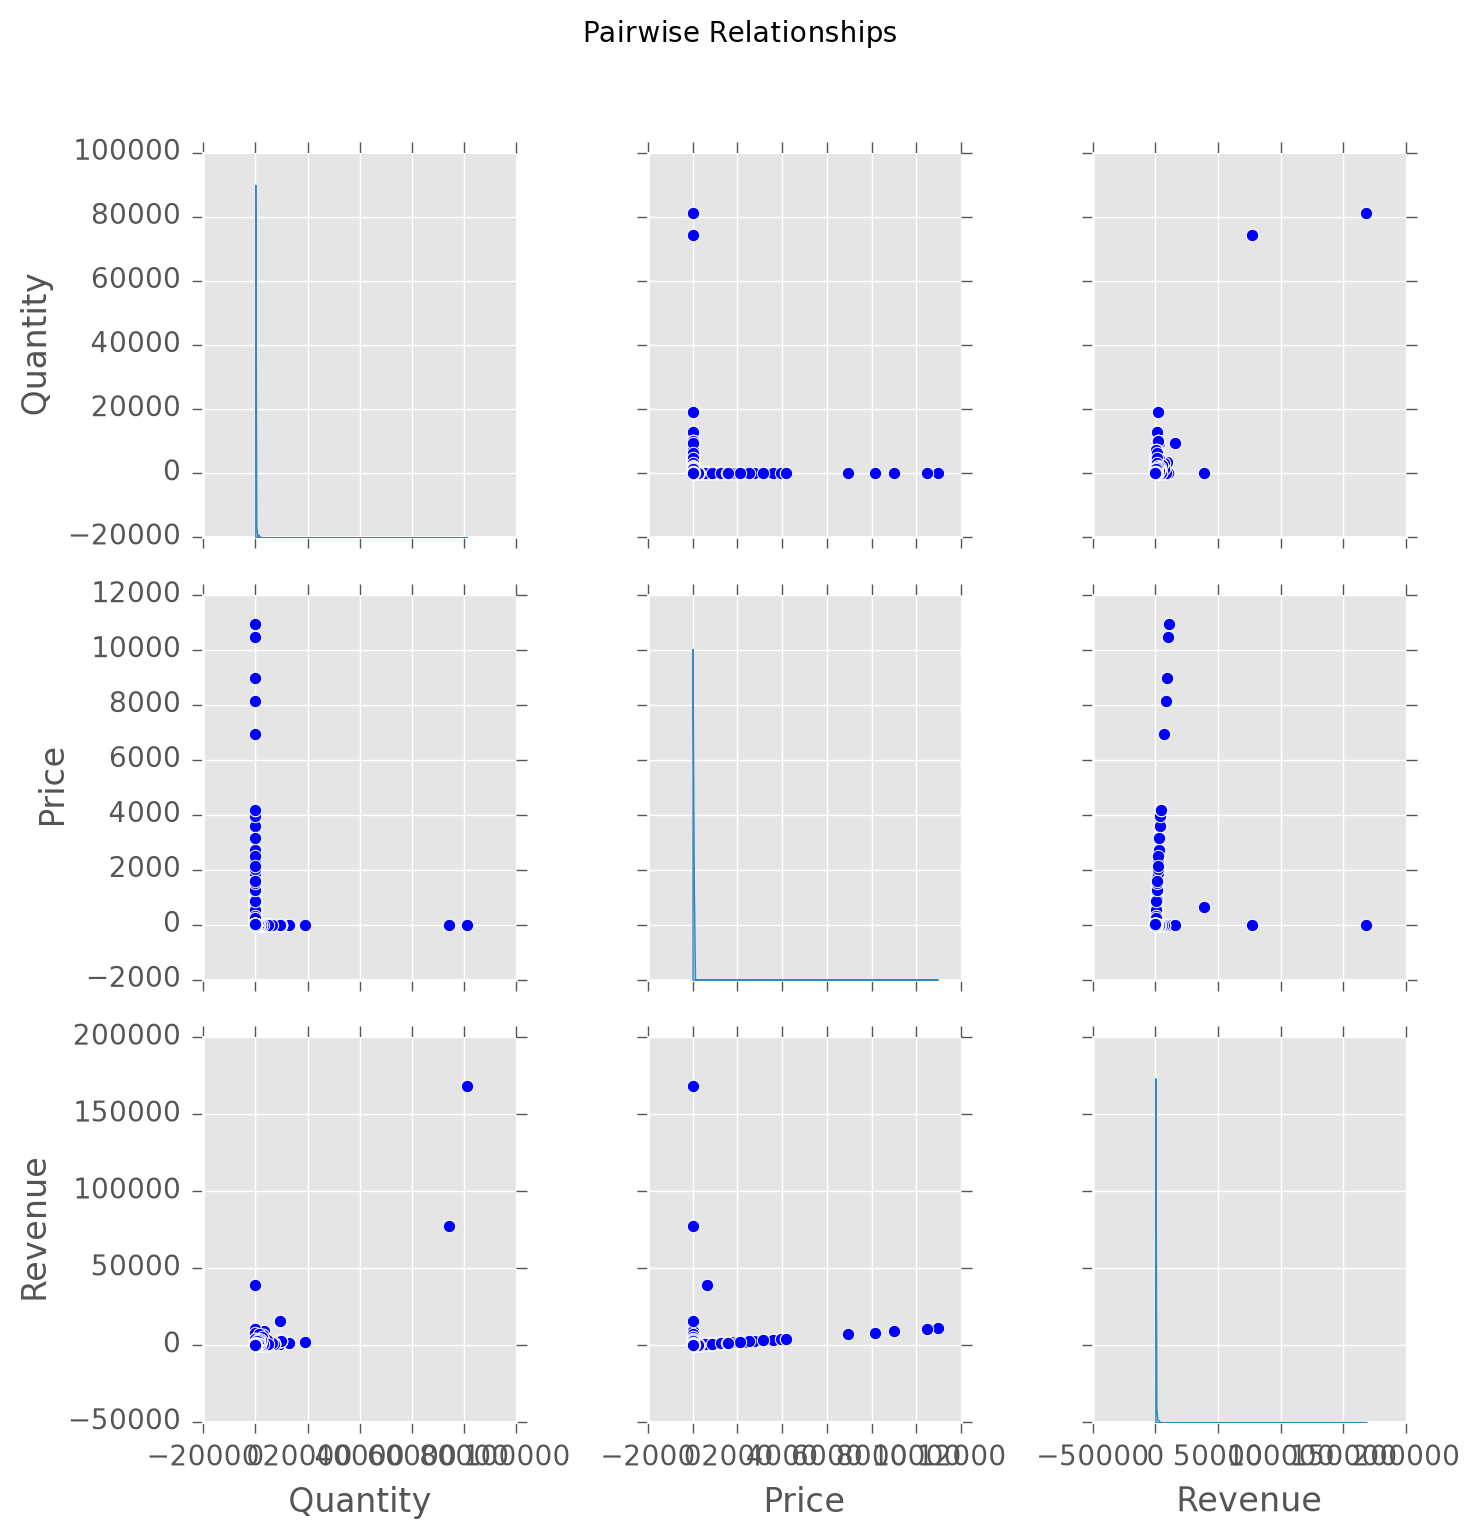

In [111]:
# 'Quantity', 'Price', 'Revenue'

# Pairs of Plots
# 'Quantity', 'Price'
# 'Quantity', 'Revenue'
# 'Price', 'Revenue'

pp = sns.pairplot(df_sample[['Quantity', 'Price', 'Revenue']], diag_kind='kde')
pp.figure.set_dpi(200)
plt.suptitle('Pairwise Relationships', y=1.02)
plt.tight_layout()
plt.show()

#### Correlation Matrix

In [112]:
corr_matrix = df_sample[['Quantity', 'Price', 'Revenue']].corr()

In [113]:
corr_matrix

,Quantity,Price,Revenue
Quantity,1.000000,-0.004909,0.826590
Price,-0.004909,1.000000,0.135897
Revenue,0.826590,0.135897,1.000000


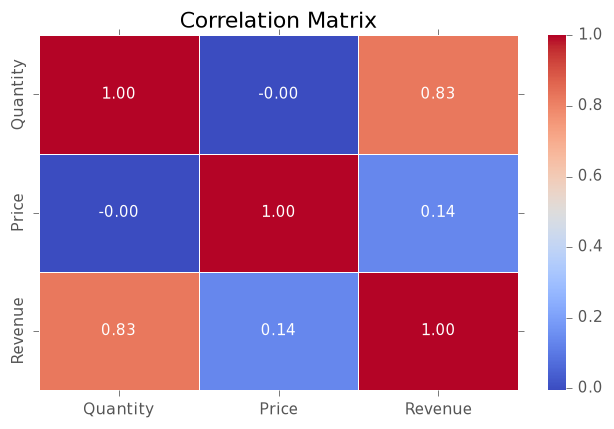

In [114]:
plt.figure(figsize=(6, 4), dpi=110)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

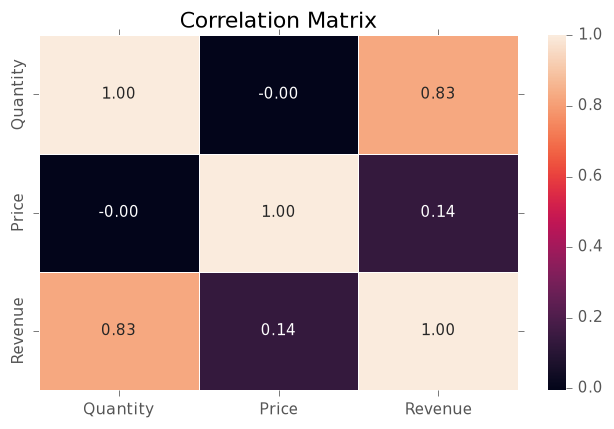

In [115]:
plt.figure(figsize=(6, 4), dpi=110)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

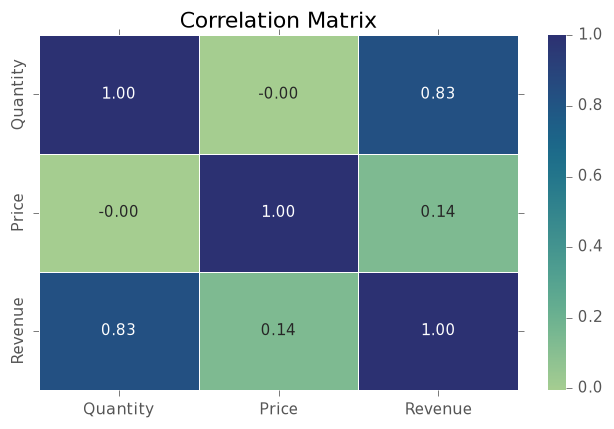

In [116]:
plt.figure(figsize=(6, 4), dpi=110)
sns.heatmap(corr_matrix, annot=True, cmap='crest', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()